# Reverberation Artifact Characterization Report

This notebook analyzes reverberation artifacts (A-line-like horizontal bands) in an ultrasound image of a **gelatinous object inside a plastic container**.

The plastic boundaries can introduce repeated reflections, producing structured horizontal echoes that may bias downstream segmentation or reconstruction.

We document multiple characterization attempts so the notebook can serve as a technical report:
1. Fourier-domain analysis (orientation and periodicity).
2. Wavelet-based multi-scale analysis (localized repetition over depth).

Visualization strategy: interactive image review is done with Napari, and matplotlib is used mainly for summary plots (histograms, spectra, and profiles).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import SimpleITK as sitk
import napari
from scipy import signal, ndimage
from skimage import exposure

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

## 1) Load One DICOM Acquisition and Apply Saved ROI Mask

To match the reconstruction notebook, this report now starts from one DICOM acquisition in `data/ultrasound/raices reales/1`.

The same manually validated ROI bounds are applied as a binary mask:

- `min_x = 401`, `max_x = 619`
- `min_y = 116`, `max_y = 689`

All downstream analysis is then repeated on the cropped masked stack (3D: frame, y, x).

In [2]:
repository_root = Path('..').resolve()
dicom_input_dir = repository_root / 'data' / 'ultrasound' / 'raices reales' / '1'
dicom_files = sorted(dicom_input_dir.glob('*.dcm'))

if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in: {dicom_input_dir}')

# Keep the same choice used in volume_reconstruction_registration_exploration.ipynb
selected_dicom_index = 0
selected_dicom_path = dicom_files[selected_dicom_index]
dataset = pydicom.dcmread(selected_dicom_path)
raw = dataset.pixel_array

# Robust shape handling: accept (z, y, x, c), (z, y, x), or a single 2D frame.
if raw.ndim == 4:
    frames = raw[..., 0]
elif raw.ndim == 3:
    frames = raw
elif raw.ndim == 2:
    frames = raw[np.newaxis, ...]
else:
    raise ValueError(f'Unsupported DICOM pixel array shape: {raw.shape}')

# Saved ROI from the reconstruction notebook.
min_x, max_x = 401, 619
min_y, max_y = 116, 689

# Clip ROI to valid bounds for safety.
y0 = max(0, min_y)
y1 = min(frames.shape[1] - 1, max_y)
x0 = max(0, min_x)
x1 = min(frames.shape[2] - 1, max_x)

if y0 > y1 or x0 > x1:
    raise ValueError('Invalid ROI after clipping. Check min/max x/y values.')

roi_mask_2d = np.zeros(frames.shape[1:], dtype=bool)
roi_mask_2d[y0:y1 + 1, x0:x1 + 1] = True

# Use the masked/cropped stack as the analysis volume.
volume = frames[:, y0:y1 + 1, x0:x1 + 1].astype(np.float32)
masked_volume_full = np.where(roi_mask_2d[None, :, :], frames, 0).astype(np.float32)

plane_count, image_height, image_width = volume.shape
column_start_index = int(image_width * 0.25)
column_end_index = int(image_width * 0.75)
depth_axis = np.arange(image_height)

print(f'Loaded DICOM: {selected_dicom_path}')
print(f'Raw pixel array shape: {raw.shape}, dtype: {raw.dtype}')
print(f'Working frame stack shape before ROI: {frames.shape}')
print(f'ROI used (from reconstruction notebook): y[{y0}:{y1}], x[{x0}:{x1}]')
print(f'Working cropped volume shape: {volume.shape}, dtype: {volume.dtype}')
print('Intensity preprocessing: no rescaling applied')
print(f'Plane count: {plane_count}')
print(f'Central-column window: [{column_start_index}, {column_end_index})')
print(f'CineRate: {dataset.get("CineRate", "N/A")} | AcquisitionTime: {dataset.get("AcquisitionTime", "N/A")}')

Loaded DICOM: C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1\001.dcm
Raw pixel array shape: (189, 768, 1024, 3), dtype: uint8
Working frame stack shape before ROI: (189, 768, 1024)
ROI used (from reconstruction notebook): y[116:689], x[401:619]
Working cropped volume shape: (189, 574, 219), dtype: float32
Intensity preprocessing: no rescaling applied
Plane count: 189
Central-column window: [54, 164)
CineRate: 19 | AcquisitionTime: 201406.235000


## Shared Helpers for the Full Report

These helpers are used across multiple analysis sections, so they are defined once here instead of being mixed into the loading cell.

Outputs introduced in this block:
- `volume`: ROI-cropped 3D stack used by all downstream analyses.
- `roi_mask_2d`: binary mask for the manually selected region of interest.
- `masked_volume_full`: full-frame stack with everything outside the ROI zeroed out.
- `column_start_index` / `column_end_index`: central-column window used for depth-profile measurements.
- `depth_axis`: pixel-depth axis for profile and spectrum plots.

In [3]:
def summarize_iqr(values: np.ndarray, axis: int = 0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return the median and interquartile range of an array along one axis."""
    median = np.median(values, axis=axis)
    percentile_25, percentile_75 = np.percentile(values, [25, 75], axis=axis)
    return median, percentile_25, percentile_75


def capture_napari_screenshot(viewer: napari.Viewer, title: str) -> None:
    """Render a Napari screenshot into a matplotlib figure for the report."""
    screenshot = viewer.screenshot(canvas_only=False, flash=False)
    print(title)
    plt.figure(figsize=(8, 5))
    plt.imshow(screenshot)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print('Shared helper functions defined: summarize_iqr, capture_napari_screenshot')

Shared helper functions defined: summarize_iqr, capture_napari_screenshot


Creating a dedicated Napari viewer for raw ROI QC...
ROI QC viewer after adding raw, mask, masked, and cropped layers


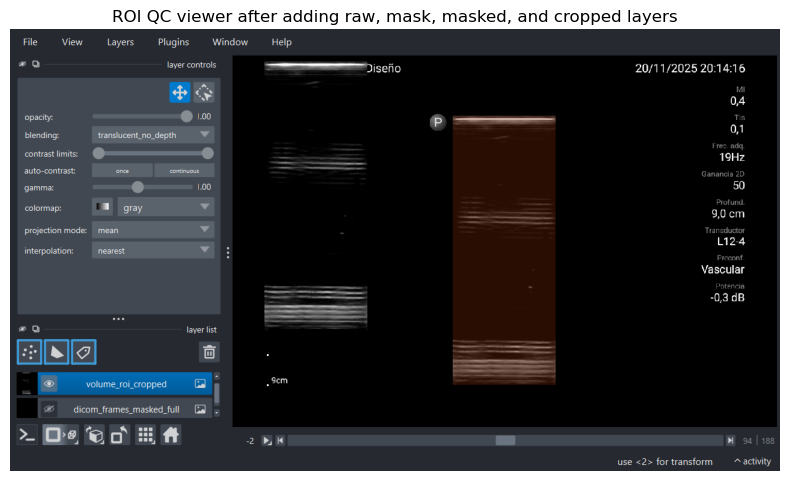

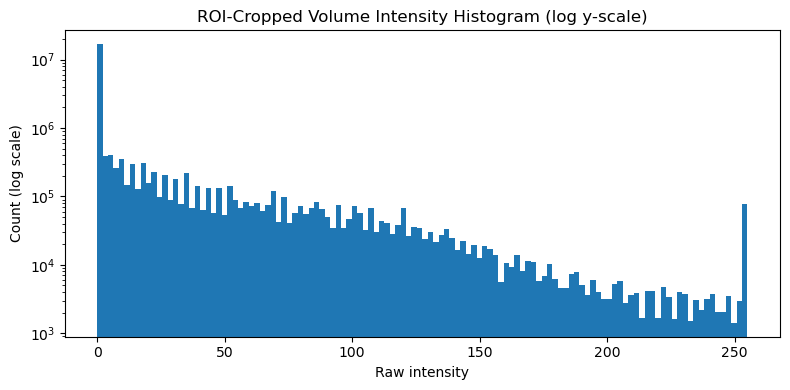

In [4]:
print('Creating a dedicated Napari viewer for raw ROI QC...')
viewer_raw_qc = napari.Viewer(title='ROI Raw QC')
viewer_raw_qc.add_image(frames.astype(np.float32), name='dicom_frames_raw', colormap='gray')
viewer_raw_qc.add_labels(roi_mask_2d.astype(np.uint8), name='roi_mask_2d', opacity=0.35)
viewer_raw_qc.add_image(masked_volume_full, name='dicom_frames_masked_full', colormap='gray', visible=False)
viewer_raw_qc.add_image(volume, name='volume_roi_cropped', colormap='gray')
capture_napari_screenshot(viewer_raw_qc, 'ROI QC viewer after adding raw, mask, masked, and cropped layers')

figure, axis = plt.subplots(1, 1, figsize=(8, 4))
axis.hist(volume.ravel(), bins=120)
axis.set_yscale('log')
axis.set_title('ROI-Cropped Volume Intensity Histogram (log y-scale)')
axis.set_xlabel('Raw intensity')
axis.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

## Section 1 Interpretation
The raw ROI QC section starts from `frames` and ends with the cropped analysis volume used by every later section.
The key outputs are `roi_mask_2d` for the manual mask, `masked_volume_full` for the full-frame masked stack, and `volume` for the ROI-cropped stack that is fed into the Fourier and wavelet analyses.
The Napari viewer here is `viewer_raw_qc`, and it is intended only for checking that the source DICOM, ROI mask, and cropped stack are aligned correctly before any filtering is applied.

## 2) Attempt A: Fourier-Domain Characterization

### Why this approach
Reverberation A-lines are approximately horizontal and often quasi-periodic in depth.
In frequency space, this should appear as structured energy at specific vertical frequencies and orientations.

### What we compute
1. A per-plane high-pass image and 2D FFT log-magnitude.
2. Plane-wise angular power spectra summarized with median and IQR.
3. Plane-wise depth profiles and depth spectra summarized with median and IQR.
4. Plane-wise spacing estimates summarized with median and IQR across the volume.

Fourier viewer after adding layer: high_pass_volume


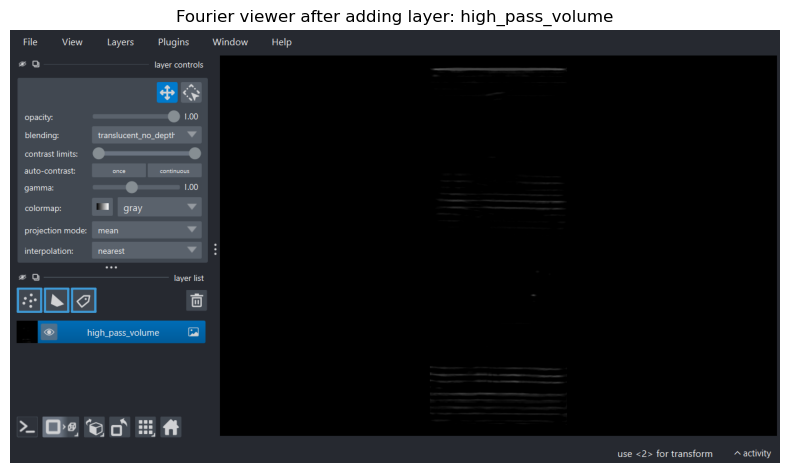

Fourier viewer after adding layer: fft_log_magnitude_volume


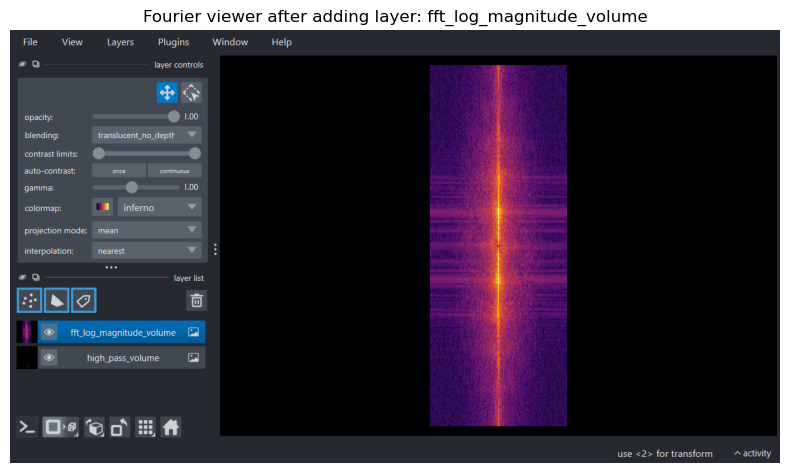

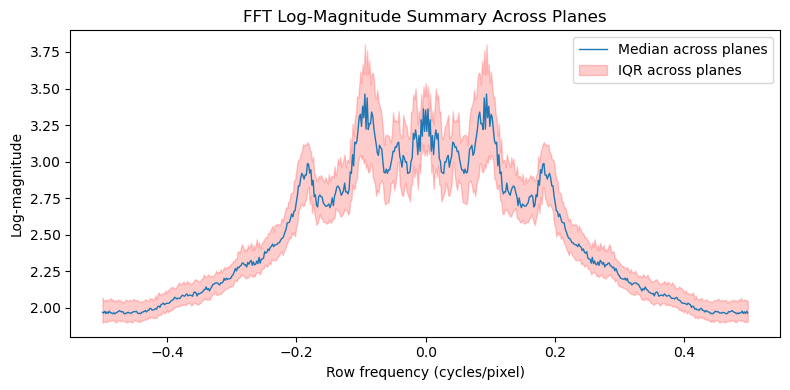

In [5]:
def compute_fft_outputs(plane: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """High-pass a plane, compute its shifted FFT, and return log magnitude."""
    low_frequency_background = ndimage.gaussian_filter(plane, sigma=(8, 8))
    high_pass_plane = plane - low_frequency_background
    high_pass_plane = (high_pass_plane - high_pass_plane.mean()) / (high_pass_plane.std() + 1e-8)
    fft = np.fft.fftshift(np.fft.fft2(high_pass_plane))
    log_magnitude = np.log1p(np.abs(fft))
    return high_pass_plane, fft, log_magnitude


# Compute high-pass and FFT outputs independently for each plane.
fft_outputs_by_plane = [compute_fft_outputs(plane) for plane in volume]
high_pass_volume = np.stack([output[0] for output in fft_outputs_by_plane], axis=0)
fft_volume = np.stack([output[1] for output in fft_outputs_by_plane], axis=0)
fft_log_magnitude_volume = np.stack([output[2] for output in fft_outputs_by_plane], axis=0)

viewer_fourier = napari.Viewer(title='Fourier-domain QC')
viewer_fourier.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume', colormap='gray')
capture_napari_screenshot(viewer_fourier, 'Fourier viewer after adding layer: high_pass_volume')
viewer_fourier.add_image(fft_log_magnitude_volume, name='fft_log_magnitude_volume', colormap='inferno')
capture_napari_screenshot(viewer_fourier, 'Fourier viewer after adding layer: fft_log_magnitude_volume')

# Summarize FFT magnitude across planes for each row-frequency index.
fft_row_profile_by_plane = np.median(fft_log_magnitude_volume, axis=2)
fft_row_median, fft_row_percentile_25, fft_row_percentile_75 = summarize_iqr(
    fft_row_profile_by_plane,
    axis=0,
 )

figure, axis = plt.subplots(1, 1, figsize=(8, 4))
row_frequency_axis = np.fft.fftshift(np.fft.fftfreq(image_height, d=1.0))
axis.plot(
    row_frequency_axis,
    fft_row_median,
    linewidth=1.0,
    label='Median across planes',
 )
axis.fill_between(
    row_frequency_axis,
    fft_row_percentile_25,
    fft_row_percentile_75,
    alpha=0.2,
    color='r',
    label='IQR across planes',
 )
axis.set_title('FFT Log-Magnitude Summary Across Planes')
axis.set_xlabel('Row frequency (cycles/pixel)')
axis.set_ylabel('Log-magnitude')
axis.legend()
plt.tight_layout()
plt.show()

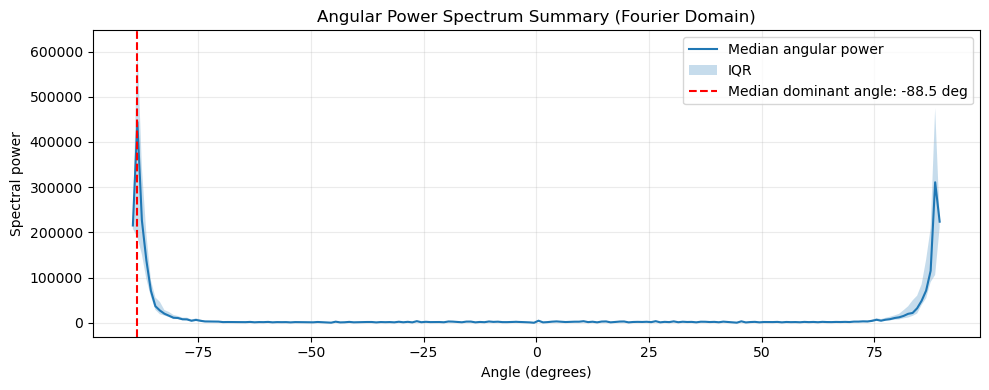

Dominant Fourier orientation across planes: median=-88.50 deg, IQR=(-88.50, 88.50) deg


In [6]:
def compute_angular_power(
    fft_plane: np.ndarray,
    frequency_mask: np.ndarray,
    angle_bin_indices: np.ndarray,
    angle_bin_count: int,
) -> np.ndarray:
    """Average shifted-FFT power per angular bin for one plane."""
    power_values = np.abs(fft_plane)[frequency_mask] ** 2
    power_sum_per_bin = np.bincount(angle_bin_indices, weights=power_values, minlength=angle_bin_count)
    sample_count_per_bin = np.bincount(angle_bin_indices, minlength=angle_bin_count)
    return np.divide(
        power_sum_per_bin,
        sample_count_per_bin,
        out=np.zeros(angle_bin_count, dtype=np.float64),
        where=sample_count_per_bin > 0,
    )


center_row_index, center_column_index = image_height // 2, image_width // 2
row_indices, column_indices = np.indices((image_height, image_width))
row_frequency_offset = row_indices - center_row_index
column_frequency_offset = column_indices - center_column_index
radial_frequency = np.sqrt(column_frequency_offset**2 + row_frequency_offset**2)
angle_degrees = np.degrees(np.arctan2(row_frequency_offset, column_frequency_offset))

# Ignore very low frequencies near DC when measuring directionality.
frequency_mask = radial_frequency > min(image_height, image_width) * 0.05
angle_bin_edges = np.linspace(-90, 90, 181)
angle_bin_count = len(angle_bin_edges) - 1
angle_bin_indices = np.digitize(angle_degrees[frequency_mask], angle_bin_edges) - 1
angle_bin_indices = np.clip(angle_bin_indices, 0, angle_bin_count - 1)
angle_bin_centers = (angle_bin_edges[:-1] + angle_bin_edges[1:]) / 2

angular_power_by_plane = np.stack(
    [
        compute_angular_power(
            fft_plane=fft_plane,
            frequency_mask=frequency_mask,
            angle_bin_indices=angle_bin_indices,
            angle_bin_count=angle_bin_count,
        )
        for fft_plane in fft_volume
    ],
    axis=0,
 )
angular_power_median, angular_power_percentile_25, angular_power_percentile_75 = summarize_iqr(angular_power_by_plane, axis=0)
dominant_angle_by_plane = angle_bin_centers[np.argmax(angular_power_by_plane, axis=1)]
dominant_angle_median, dominant_angle_percentile_25, dominant_angle_percentile_75 = summarize_iqr(
    dominant_angle_by_plane, axis=0
 )

plt.figure(figsize=(10, 4))
plt.plot(angle_bin_centers, angular_power_median, label='Median angular power')
plt.fill_between(
    angle_bin_centers,
    angular_power_percentile_25,
    angular_power_percentile_75,
    alpha=0.25,
    label='IQR',
 )
plt.axvline(
    dominant_angle_median,
    color='r',
    linestyle='--',
    label=f'Median dominant angle: {dominant_angle_median:.1f} deg',
 )
plt.title('Angular Power Spectrum Summary (Fourier Domain)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Spectral power')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(
    'Dominant Fourier orientation across planes: '
    f'median={dominant_angle_median:.2f} deg, '
    f'IQR=({dominant_angle_percentile_25:.2f}, {dominant_angle_percentile_75:.2f}) deg'
 )

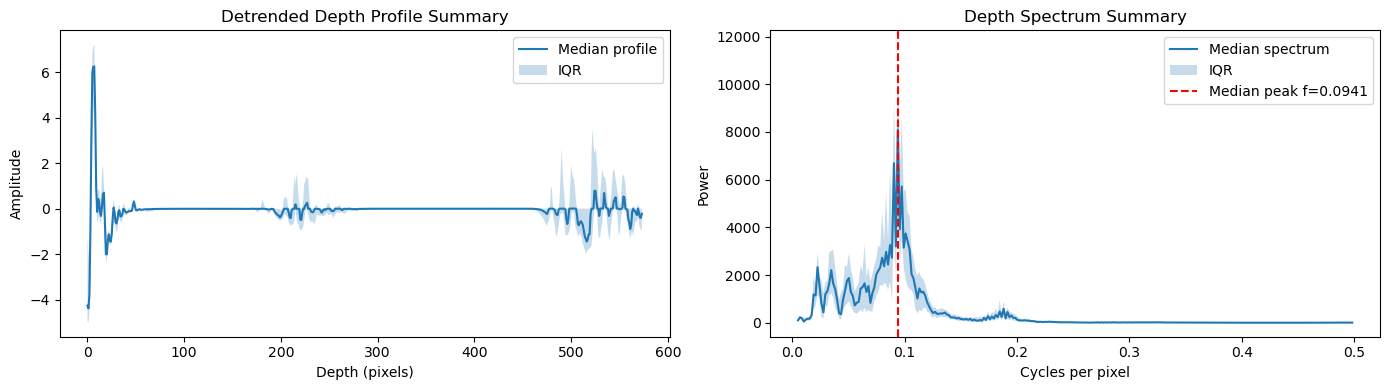

Estimated A-line spacing (Fourier): median=10.63 px, IQR=(10.44, 10.83) px


In [7]:
def compute_depth_profile_outputs(
    high_pass_plane: np.ndarray,
    start_column_index: int,
    end_column_index: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Average the central columns of a high-pass plane and return profile spectrum outputs."""
    depth_profile = high_pass_plane[:, start_column_index:end_column_index].mean(axis=1)
    depth_profile = signal.detrend(depth_profile)
    power_spectrum = np.abs(np.fft.rfft(depth_profile)) ** 2
    frequency_axis = np.fft.rfftfreq(depth_profile.size, d=1.0)
    return depth_profile, frequency_axis, power_spectrum


# Estimate periodic depth spacing plane-by-plane by averaging central columns.
depth_profile_results_by_plane = [
    compute_depth_profile_outputs(high_pass_plane, column_start_index, column_end_index)
    for high_pass_plane in high_pass_volume
]
depth_profiles_by_plane = np.stack([result[0] for result in depth_profile_results_by_plane], axis=0)
frequency_axis = depth_profile_results_by_plane[0][1]
power_spectrum_by_plane = np.stack([result[2] for result in depth_profile_results_by_plane], axis=0)

valid_frequency_mask = (frequency_axis > 0.005) & (frequency_axis < 0.5)
valid_frequency_axis = frequency_axis[valid_frequency_mask]
valid_power_spectrum_by_plane = power_spectrum_by_plane[:, valid_frequency_mask]
peak_index_by_plane = np.argmax(valid_power_spectrum_by_plane, axis=1)
peak_frequency_by_plane = valid_frequency_axis[peak_index_by_plane]
spacing_by_plane = np.divide(
    1.0,
    peak_frequency_by_plane,
    out=np.full_like(peak_frequency_by_plane, np.nan, dtype=np.float64),
    where=peak_frequency_by_plane > 0,
)

depth_profile_median, depth_profile_percentile_25, depth_profile_percentile_75 = summarize_iqr(
    depth_profiles_by_plane, axis=0
)
power_spectrum_median, power_spectrum_percentile_25, power_spectrum_percentile_75 = summarize_iqr(
    valid_power_spectrum_by_plane, axis=0
)
peak_frequency_median, _, _ = summarize_iqr(peak_frequency_by_plane, axis=0)
spacing_median, spacing_percentile_25, spacing_percentile_75 = summarize_iqr(spacing_by_plane, axis=0)

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(depth_axis, depth_profile_median, label='Median profile')
axis_array[0].fill_between(
    depth_axis,
    depth_profile_percentile_25,
    depth_profile_percentile_75,
    alpha=0.25,
    label='IQR',
)
axis_array[0].set_title('Detrended Depth Profile Summary')
axis_array[0].set_xlabel('Depth (pixels)')
axis_array[0].set_ylabel('Amplitude')
axis_array[0].legend()

axis_array[1].plot(valid_frequency_axis, power_spectrum_median, label='Median spectrum')
axis_array[1].fill_between(
    valid_frequency_axis,
    power_spectrum_percentile_25,
    power_spectrum_percentile_75,
    alpha=0.25,
    label='IQR',
)
axis_array[1].axvline(
    peak_frequency_median,
    color='r',
    linestyle='--',
    label=f'Median peak f={peak_frequency_median:.4f}',
)
axis_array[1].set_title('Depth Spectrum Summary')
axis_array[1].set_xlabel('Cycles per pixel')
axis_array[1].set_ylabel('Power')
axis_array[1].legend()

plt.tight_layout()
plt.show()

print(
    'Estimated A-line spacing (Fourier): '
    f'median={spacing_median:.2f} px, '
    f'IQR=({spacing_percentile_25:.2f}, {spacing_percentile_75:.2f}) px'
 )

### Napari Review of Candidate Reverberation Bands

To complement the frequency plots, we create a simple candidate mask of horizontal reverberation bands from the high-pass image and inspect it as an overlay in Napari.

This is intentionally heuristic and meant for interactive QA rather than final segmentation.

Candidate reverberation voxels: 1316409 / 23758434
Adding 3D artifact-mask labels to the same Napari viewer...
Napari after adding layer: artifact_mask_volume


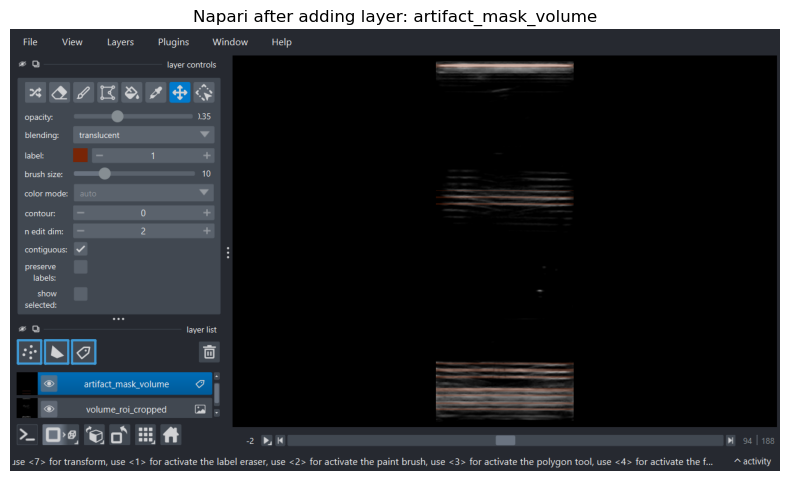

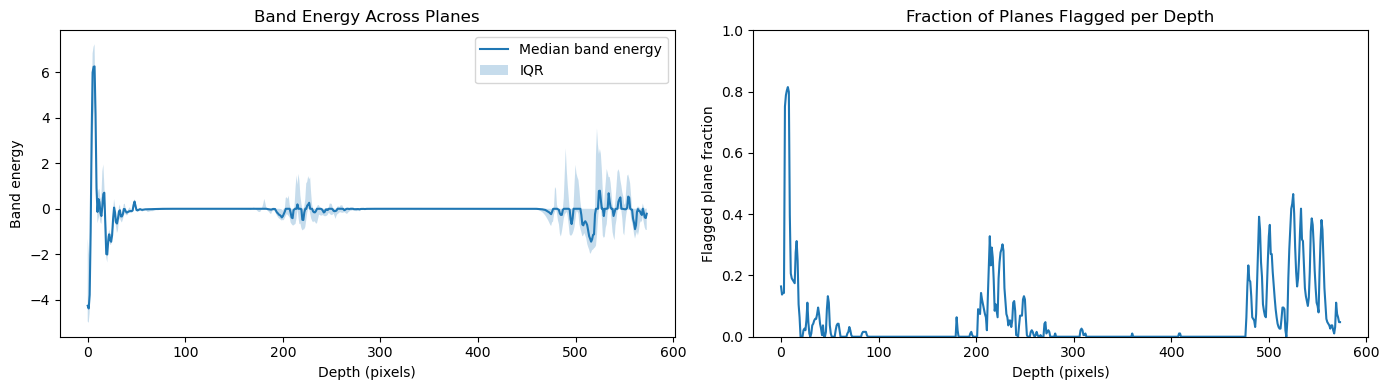

In [8]:
# Build a simple 3D mask of strong positive horizontal bands from per-plane band-energy profiles.
band_energy_by_plane = high_pass_volume[:, :, column_start_index:column_end_index].mean(axis=2)
band_energy_threshold_by_plane = band_energy_by_plane.mean(axis=1, keepdims=True) + 1.2 * band_energy_by_plane.std(
    axis=1, keepdims=True
)
artifact_row_mask_by_plane = band_energy_by_plane > band_energy_threshold_by_plane

artifact_mask_volume = np.broadcast_to(artifact_row_mask_by_plane[:, :, None], volume.shape).copy()
artifact_mask_volume = ndimage.binary_opening(
    artifact_mask_volume,
    structure=np.ones((1, 1, 9), dtype=bool),
)
artifact_row_fraction_by_depth = artifact_row_mask_by_plane.mean(axis=0)
band_energy_median, band_energy_percentile_25, band_energy_percentile_75 = summarize_iqr(
    band_energy_by_plane, axis=0
)

print(f'Candidate reverberation voxels: {artifact_mask_volume.sum()} / {artifact_mask_volume.size}')
print('Adding 3D artifact-mask labels to the same Napari viewer...')
viewer = napari.Viewer(title='Artifact Mask QC')
viewer.add_image(volume, name='volume_roi_cropped', colormap='gray')
viewer.add_labels(
    artifact_mask_volume.astype(np.uint8),
    name='artifact_mask_volume',
    opacity=0.35,
)
capture_napari_screenshot(viewer, 'Napari after adding layer: artifact_mask_volume')

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(depth_axis, band_energy_median, label='Median band energy')
axis_array[0].fill_between(
    depth_axis,
    band_energy_percentile_25,
    band_energy_percentile_75,
    alpha=0.25,
    label='IQR',
)
axis_array[0].set_title('Band Energy Across Planes')
axis_array[0].set_xlabel('Depth (pixels)')
axis_array[0].set_ylabel('Band energy')
axis_array[0].legend()

axis_array[1].plot(depth_axis, artifact_row_fraction_by_depth)
axis_array[1].set_title('Fraction of Planes Flagged per Depth')
axis_array[1].set_xlabel('Depth (pixels)')
axis_array[1].set_ylabel('Flagged plane fraction')
axis_array[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

## Section 2 Interpretation
This Fourier block starts from `volume`, produces `high_pass_volume`, `fft_volume`, and `fft_log_magnitude_volume`, and then summarizes orientation and spacing across all planes.
`angular_power_by_plane` and `dominant_angle_by_plane` describe the directionality of the FFT energy, while `depth_profiles_by_plane`, `power_spectrum_by_plane`, `peak_frequency_by_plane`, and `spacing_by_plane` quantify the repeated depth spacing.
The dedicated viewer `viewer_fourier` is the inspection surface for the Fourier section, and the final outputs of this section are the median/IQR plots plus the spacing estimate reported from the depth spectrum.

## 3) Attempt B: Wavelet-Based Characterization

### Why this approach
Fourier analysis gives global periodicity, but reverberation can vary with depth.
Wavelets provide **joint depth-frequency localization**, which helps identify where repetition is strongest.

### What we compute
1. A plane-wise depth profile from central columns.
2. A wavelet transform for each plane.
3. Median and IQR summaries of the plane-wise depth profiles, scalograms, and global wavelet spectra.
4. A plane-wise spacing estimate summarized with median and IQR across the volume.

Napari is used for 3D image and mask inspection, while matplotlib is kept for quantitative summary plots.

Wavelet viewer after adding layer: high_pass_volume_for_wavelet


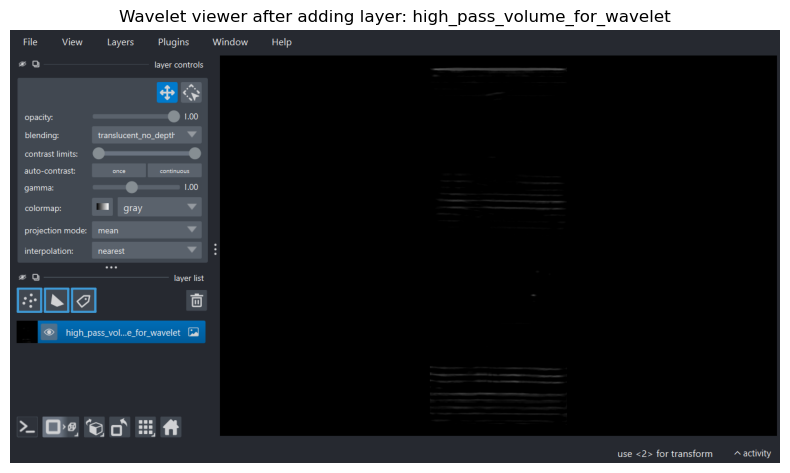

Wavelet viewer after adding layer: wavelet_energy_median


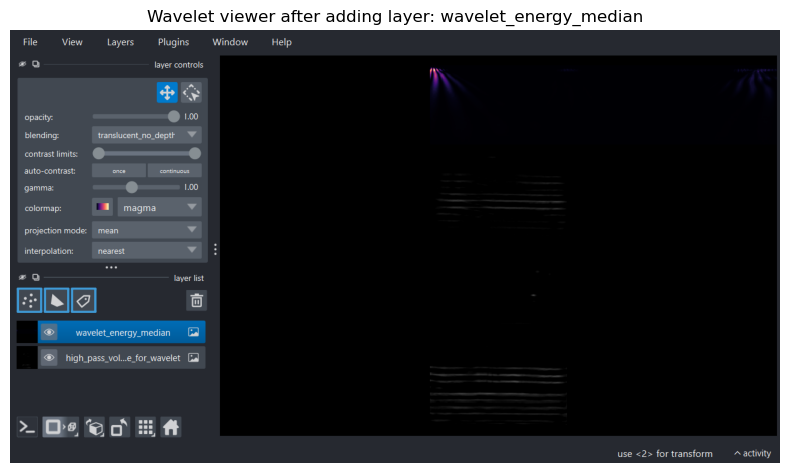

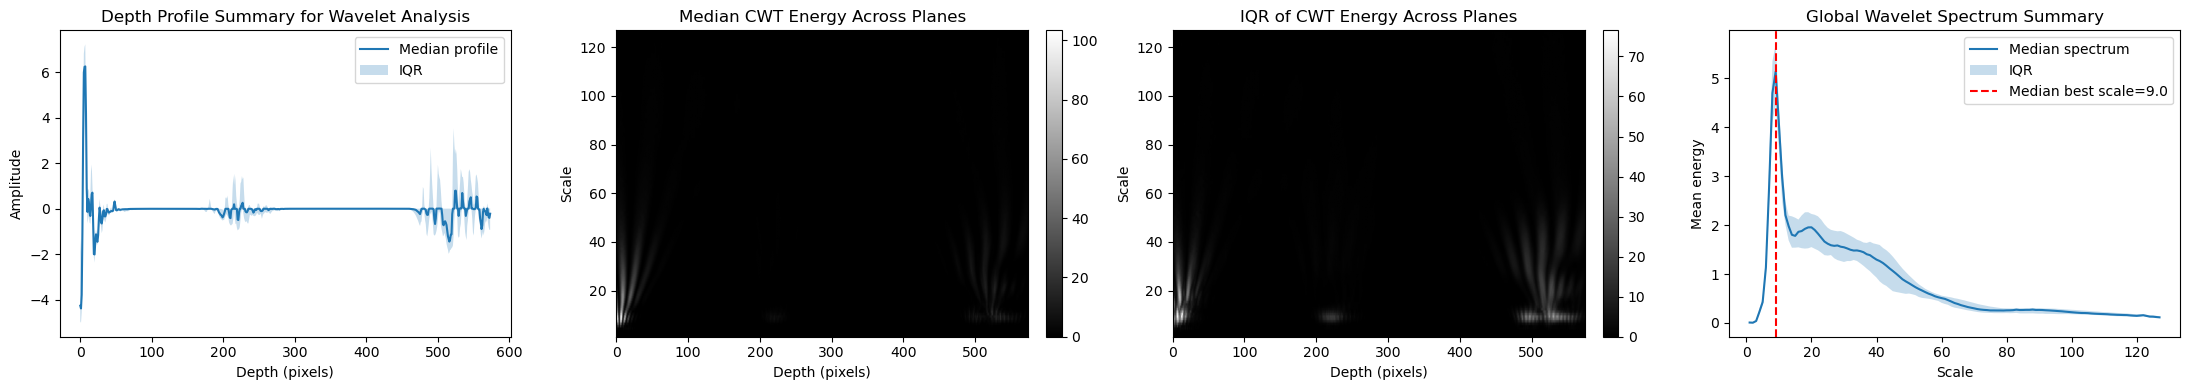

Estimated A-line spacing (Wavelet, approx): median=9.00 px, IQR=(8.00, 9.00) px


In [9]:
import pywt

def compute_wavelet_outputs(
    high_pass_plane: np.ndarray,
    start_column_index: int,
    end_column_index: int,
    scale_values: np.ndarray,
    wavelet: str = 'morl',
 ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """Compute the wavelet-based depth profile, coefficients, and summary spectra for one plane."""
    depth_profile = high_pass_plane[:, start_column_index:end_column_index].mean(axis=1)
    depth_profile = signal.detrend(depth_profile)
    wavelet_coefficients, wavelet_frequency_axis = pywt.cwt(depth_profile, scale_values, wavelet)
    wavelet_energy_map = np.abs(wavelet_coefficients) ** 2
    global_energy_spectrum = wavelet_energy_map.mean(axis=1)
    best_scale_value = float(scale_values[np.argmax(global_energy_spectrum)])
    return (
        depth_profile,
        wavelet_coefficients,
        wavelet_frequency_axis,
        wavelet_energy_map,
        global_energy_spectrum,
        best_scale_value,
    )


viewer_wavelet = napari.Viewer(title='Wavelet-domain QC')
viewer_wavelet.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume_for_wavelet', colormap='gray')
capture_napari_screenshot(viewer_wavelet, 'Wavelet viewer after adding layer: high_pass_volume_for_wavelet')

scale_values = np.arange(1, 128)
wavelet_results_by_plane = [
    compute_wavelet_outputs(high_pass_plane, column_start_index, column_end_index, scale_values)
    for high_pass_plane in high_pass_volume
]
wavelet_profile_by_plane = np.stack([result[0] for result in wavelet_results_by_plane], axis=0)
wavelet_energy_by_plane = np.stack([result[3] for result in wavelet_results_by_plane], axis=0)
global_wavelet_spectrum_by_plane = np.stack([result[4] for result in wavelet_results_by_plane], axis=0)
best_scale_by_plane = np.array([result[5] for result in wavelet_results_by_plane], dtype=np.float64)

wavelet_spacing_median, wavelet_spacing_percentile_25, wavelet_spacing_percentile_75 = summarize_iqr(
    best_scale_by_plane, axis=0
)
wavelet_profile_median, wavelet_profile_percentile_25, wavelet_profile_percentile_75 = summarize_iqr(
    wavelet_profile_by_plane, axis=0
)
wavelet_energy_median, wavelet_energy_percentile_25, wavelet_energy_percentile_75 = summarize_iqr(
    wavelet_energy_by_plane, axis=0
)
wavelet_energy_iqr = wavelet_energy_percentile_75 - wavelet_energy_percentile_25
global_wavelet_spectrum_median, global_wavelet_spectrum_percentile_25, global_wavelet_spectrum_percentile_75 = summarize_iqr(
    global_wavelet_spectrum_by_plane, axis=0
)

wavelet_median_preview = wavelet_energy_median.astype(np.float32)
viewer_wavelet.add_image(wavelet_median_preview, contrast_limits=[0, wavelet_median_preview.max()], name='wavelet_energy_median', colormap='magma')
capture_napari_screenshot(viewer_wavelet, 'Wavelet viewer after adding layer: wavelet_energy_median')

figure, axis_array = plt.subplots(1, 4, figsize=(22, 4))
axis_array[0].plot(depth_axis, wavelet_profile_median, label='Median profile')
axis_array[0].fill_between(
    depth_axis,
    wavelet_profile_percentile_25,
    wavelet_profile_percentile_75,
    alpha=0.25,
    label='IQR',
)
axis_array[0].set_title('Depth Profile Summary for Wavelet Analysis')
axis_array[0].set_xlabel('Depth (pixels)')
axis_array[0].set_ylabel('Amplitude')
axis_array[0].legend()

wavelet_median_image = axis_array[1].imshow(
    wavelet_energy_median,
    aspect='auto',
    origin='lower',
    extent=[0, wavelet_profile_by_plane.shape[1], scale_values.min(), scale_values.max()],
)
axis_array[1].set_title('Median CWT Energy Across Planes')
axis_array[1].set_xlabel('Depth (pixels)')
axis_array[1].set_ylabel('Scale')
plt.colorbar(wavelet_median_image, ax=axis_array[1], fraction=0.046, pad=0.04)

wavelet_iqr_image = axis_array[2].imshow(
    wavelet_energy_iqr,
    aspect='auto',
    origin='lower',
    extent=[0, wavelet_profile_by_plane.shape[1], scale_values.min(), scale_values.max()],
)
axis_array[2].set_title('IQR of CWT Energy Across Planes')
axis_array[2].set_xlabel('Depth (pixels)')
axis_array[2].set_ylabel('Scale')
plt.colorbar(wavelet_iqr_image, ax=axis_array[2], fraction=0.046, pad=0.04)

axis_array[3].plot(scale_values, global_wavelet_spectrum_median, label='Median spectrum')
axis_array[3].fill_between(
    scale_values,
    global_wavelet_spectrum_percentile_25,
    global_wavelet_spectrum_percentile_75,
    alpha=0.25,
    label='IQR',
)
axis_array[3].axvline(
    wavelet_spacing_median,
    color='r',
    linestyle='--',
    label=f'Median best scale={wavelet_spacing_median:.1f}',
)
axis_array[3].set_title('Global Wavelet Spectrum Summary')
axis_array[3].set_xlabel('Scale')
axis_array[3].set_ylabel('Mean energy')
axis_array[3].legend()

plt.tight_layout()
plt.show()

print(
    'Estimated A-line spacing (Wavelet, approx): '
    f'median={wavelet_spacing_median:.2f} px, '
    f'IQR=({wavelet_spacing_percentile_25:.2f}, {wavelet_spacing_percentile_75:.2f}) px'
 )

## Section 3 Interpretation
The wavelet block starts from `high_pass_volume` and produces `wavelet_profile_by_plane`, `wavelet_energy_by_plane`, `global_wavelet_spectrum_by_plane`, and `best_scale_by_plane` for all planes.
`wavelet_spacing_median` is the global scale estimate, while `wavelet_energy_median` and `wavelet_energy_iqr` show where wavelet energy is concentrated and how much that concentration varies across planes.
The dedicated viewer `viewer_wavelet` holds the wavelet-section inspection layers, and the main conclusion is whether the repeated depth structure is stable enough to support scale-selective suppression.

## Final Interpretation
This report closes with the cleaned-volume comparison across `high_pass_volume`, `swt_vol_filtered`, `comb_filtered_vol`, `final_cleaned_vol`, and `final_tail_cleaned_vol`.
The final metrics to read are the artifact-mask fractions, the correlation and RMSE values, and the gradient-energy ratio, because together they show how much reverberation-like structure was removed and how much anatomical structure was preserved.
The final reconstructed display is `final_tail_cleaned_restored_volume`, which should be treated as the report’s best visual candidate after all suppression stages.

## 6) Physical-Unit Conversion and Notch-Filter Design Hints

This section translates the spacing estimates from pixels to millimeters using image metadata, then proposes practical notch-band parameters around the detected reverberation frequency.

The goal is to provide directly actionable values for suppression experiments while keeping the current report descriptive and reproducible.

In [10]:
# Try to extract pixel spacing from DICOM metadata.
# DICOM PixelSpacing = [row_spacing_mm, col_spacing_mm] = [y_spacing, x_spacing].
# Fall back to the same values used in volume_reconstruction_registration_exploration.ipynb.
_default_spacing_x_mm = 0.187
_default_spacing_y_mm = 0.188
_default_spacing_z_mm = 3.95

try:
    _ps = dataset.PixelSpacing
    image_spacing_x_mm = float(_ps[1])  # column spacing -> x
    image_spacing_y_mm = float(_ps[0])  # row spacing -> y
except AttributeError:
    image_spacing_x_mm = _default_spacing_x_mm
    image_spacing_y_mm = _default_spacing_y_mm

# Frame-to-frame z-spacing is not stored in standard DICOM cine sequences.
image_spacing_z_mm = _default_spacing_z_mm

print(f'Pixel spacing (mm): x={image_spacing_x_mm:.4f}, y={image_spacing_y_mm:.4f}, z={image_spacing_z_mm:.4f}')

fourier_spacing_median_mm = spacing_median * image_spacing_y_mm
fourier_spacing_percentile_25_mm = spacing_percentile_25 * image_spacing_y_mm
fourier_spacing_percentile_75_mm = spacing_percentile_75 * image_spacing_y_mm

wavelet_spacing_median_mm = wavelet_spacing_median * image_spacing_y_mm
wavelet_spacing_percentile_25_mm = wavelet_spacing_percentile_25 * image_spacing_y_mm
wavelet_spacing_percentile_75_mm = wavelet_spacing_percentile_75 * image_spacing_y_mm

peak_frequency_percentile_25, peak_frequency_percentile_75 = np.percentile(
    peak_frequency_by_plane,
    [25, 75],
)

# Convert vertical frequency from cycles/pixel to cycles/mm using row spacing.
peak_frequency_median_cycles_per_mm = peak_frequency_median / image_spacing_y_mm
peak_frequency_percentile_25_cycles_per_mm = peak_frequency_percentile_25 / image_spacing_y_mm
peak_frequency_percentile_75_cycles_per_mm = peak_frequency_percentile_75 / image_spacing_y_mm

peak_frequency_iqr = peak_frequency_percentile_75 - peak_frequency_percentile_25
default_notch_half_width = max(0.005, 0.1 * peak_frequency_median)
notch_half_width_cycles_per_pixel = max(1.5 * peak_frequency_iqr, default_notch_half_width)

notch_low_cycles_per_pixel = max(0.0, peak_frequency_median - notch_half_width_cycles_per_pixel)
notch_high_cycles_per_pixel = min(0.5, peak_frequency_median + notch_half_width_cycles_per_pixel)

notch_low_cycles_per_mm = notch_low_cycles_per_pixel / image_spacing_y_mm
notch_high_cycles_per_mm = notch_high_cycles_per_pixel / image_spacing_y_mm

print('Voxel spacing from metadata (x, y, z) [mm]:')
print(f'({image_spacing_x_mm:.4f}, {image_spacing_y_mm:.4f}, {image_spacing_z_mm:.4f})')
print()
print('Spacing estimates converted to mm (row/depth direction):')
print(
    f'Fourier spacing median={fourier_spacing_median_mm:.3f} mm, '
    f'IQR=({fourier_spacing_percentile_25_mm:.3f}, {fourier_spacing_percentile_75_mm:.3f}) mm'
 )
print(
    f'Wavelet spacing median={wavelet_spacing_median_mm:.3f} mm, '
    f'IQR=({wavelet_spacing_percentile_25_mm:.3f}, {wavelet_spacing_percentile_75_mm:.3f}) mm'
 )
print()
print('Suggested notch band around detected reverberation frequency:')
print(
    f'cycles/pixel: center={peak_frequency_median:.5f}, '
    f'band=[{notch_low_cycles_per_pixel:.5f}, {notch_high_cycles_per_pixel:.5f}]'
 )
print(
    f'cycles/mm: center={peak_frequency_median_cycles_per_mm:.5f}, '
    f'band=[{notch_low_cycles_per_mm:.5f}, {notch_high_cycles_per_mm:.5f}]'
 )

Pixel spacing (mm): x=15.6661, y=15.6661, z=3.9500
Voxel spacing from metadata (x, y, z) [mm]:
(15.6661, 15.6661, 3.9500)

Spacing estimates converted to mm (row/depth direction):
Fourier spacing median=166.525 mm, IQR=(163.497, 169.667) mm
Wavelet spacing median=140.995 mm, IQR=(125.329, 140.995) mm

Suggested notch band around detected reverberation frequency:
cycles/pixel: center=0.09408, band=[0.08467, 0.10348]
cycles/mm: center=0.00601, band=[0.00540, 0.00661]


## 7) Notch Suppression Prototype and Before/After Comparison

This section applies a simple Fourier-domain notch filter around the detected reverberation band and compares pre/post summaries.

The filter is defined on the row-frequency axis and removes both positive and negative bands at the same absolute frequency.

Hard-notch viewer after adding baseline and filtered high-pass volumes


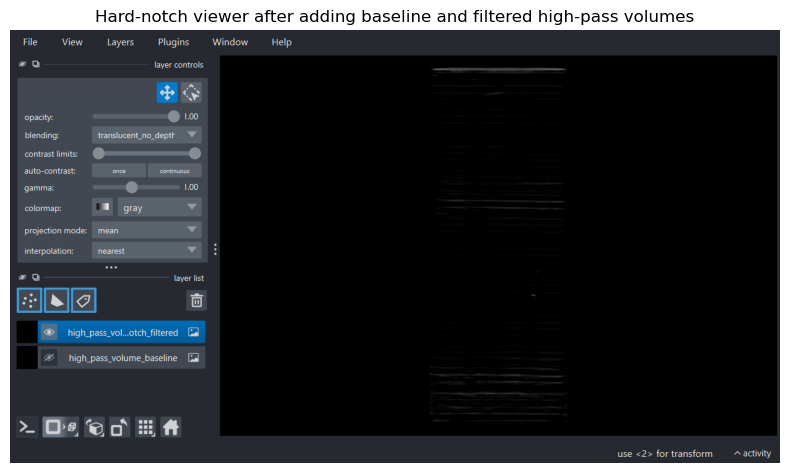

Hard-notch viewer after adding baseline and filtered FFT log-magnitude volumes


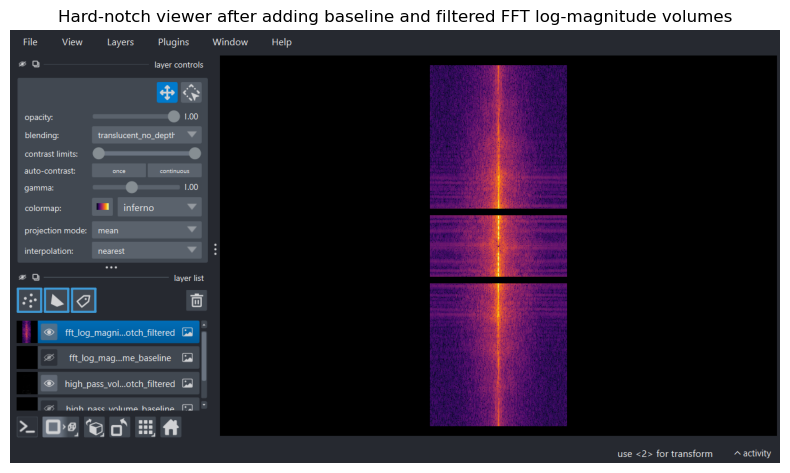

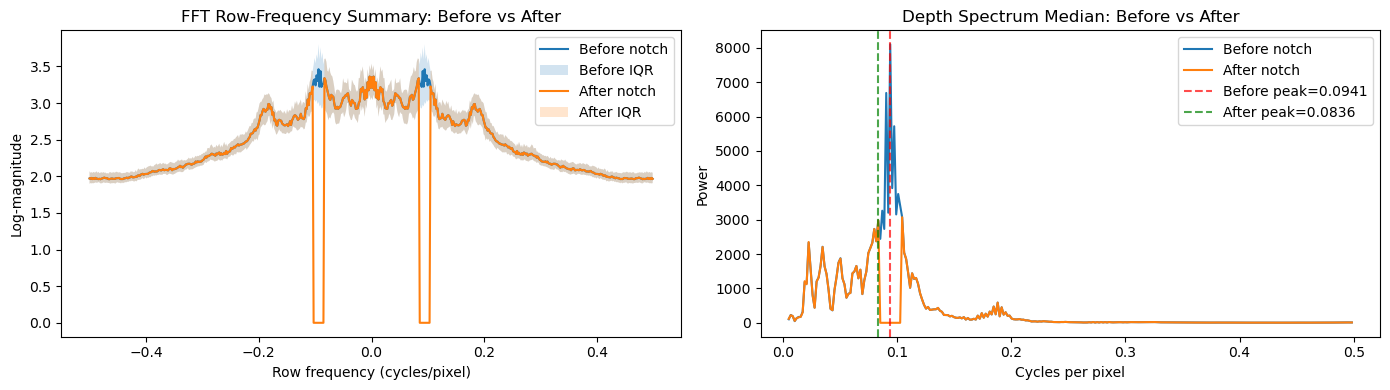

Estimated A-line spacing after notch (Fourier): median=11.96 px, IQR=(9.57, 12.76) px


In [11]:
# Build a 2D notch filter on row frequencies (applied symmetrically at +/- target band).
row_frequency_axis = np.fft.fftshift(np.fft.fftfreq(image_height, d=1.0))
notch_band_mask = (np.abs(row_frequency_axis) >= notch_low_cycles_per_pixel) & (
    np.abs(row_frequency_axis) <= notch_high_cycles_per_pixel
)

notch_filter_2d = np.ones((image_height, image_width), dtype=np.float32)
notch_filter_2d[notch_band_mask, :] = 0.0

# Apply notch filter to each plane in shifted FFT space, then invert back to high-pass image space.
filtered_fft_volume = fft_volume * notch_filter_2d[None, :, :]
filtered_high_pass_volume = np.fft.ifft2(
    np.fft.ifftshift(filtered_fft_volume, axes=(1, 2)),
    axes=(1, 2),
).real
filtered_fft_log_magnitude_volume = np.log1p(np.abs(filtered_fft_volume))

viewer_notch = napari.Viewer(title='Hard Notch QC')
viewer_notch.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume_baseline', colormap='gray', visible=False)
viewer_notch.add_image(filtered_high_pass_volume, contrast_limits=[0, filtered_high_pass_volume.max()], name='high_pass_volume_notch_filtered', colormap='gray')
capture_napari_screenshot(viewer_notch, 'Hard-notch viewer after adding baseline and filtered high-pass volumes')
viewer_notch.add_image(fft_log_magnitude_volume, name='fft_log_magnitude_volume_baseline', colormap='inferno', visible=False)
viewer_notch.add_image(
    filtered_fft_log_magnitude_volume,
    name='fft_log_magnitude_volume_notch_filtered',
    colormap='inferno',
)
capture_napari_screenshot(viewer_notch, 'Hard-notch viewer after adding baseline and filtered FFT log-magnitude volumes')

# Compare row-frequency summaries before and after filtering.
fft_row_profile_before = np.median(fft_log_magnitude_volume, axis=2)
fft_row_before_median, fft_row_before_percentile_25, fft_row_before_percentile_75 = summarize_iqr(
    fft_row_profile_before, axis=0
)
fft_row_profile_after = np.median(filtered_fft_log_magnitude_volume, axis=2)
fft_row_after_median, fft_row_after_percentile_25, fft_row_after_percentile_75 = summarize_iqr(
    fft_row_profile_after, axis=0
)

# Compare spacing estimates before and after filtering in high-pass domain.
filtered_depth_results_by_plane = [
    compute_depth_profile_outputs(filtered_plane, column_start_index, column_end_index)
    for filtered_plane in filtered_high_pass_volume
]
filtered_power_spectrum_by_plane = np.stack([result[2] for result in filtered_depth_results_by_plane], axis=0)
filtered_valid_power_spectrum_by_plane = filtered_power_spectrum_by_plane[:, valid_frequency_mask]
filtered_peak_index_by_plane = np.argmax(filtered_valid_power_spectrum_by_plane, axis=1)
filtered_peak_frequency_by_plane = valid_frequency_axis[filtered_peak_index_by_plane]
filtered_spacing_by_plane = np.divide(
    1.0,
    filtered_peak_frequency_by_plane,
    out=np.full_like(filtered_peak_frequency_by_plane, np.nan, dtype=np.float64),
    where=filtered_peak_frequency_by_plane > 0,
)

filtered_peak_frequency_median, _, _ = summarize_iqr(filtered_peak_frequency_by_plane, axis=0)
filtered_spacing_median, filtered_spacing_percentile_25, filtered_spacing_percentile_75 = summarize_iqr(
    filtered_spacing_by_plane, axis=0
)

power_spectrum_before_median, _, _ = summarize_iqr(valid_power_spectrum_by_plane, axis=0)
power_spectrum_after_median, _, _ = summarize_iqr(filtered_valid_power_spectrum_by_plane, axis=0)

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(row_frequency_axis, fft_row_before_median, label='Before notch')
axis_array[0].fill_between(
    row_frequency_axis,
    fft_row_before_percentile_25,
    fft_row_before_percentile_75,
    alpha=0.2,
    label='Before IQR',
)
axis_array[0].plot(row_frequency_axis, fft_row_after_median, label='After notch')
axis_array[0].fill_between(
    row_frequency_axis,
    fft_row_after_percentile_25,
    fft_row_after_percentile_75,
    alpha=0.2,
    label='After IQR',
)
axis_array[0].set_title('FFT Row-Frequency Summary: Before vs After')
axis_array[0].set_xlabel('Row frequency (cycles/pixel)')
axis_array[0].set_ylabel('Log-magnitude')
axis_array[0].legend()

axis_array[1].plot(valid_frequency_axis, power_spectrum_before_median, label='Before notch')
axis_array[1].plot(valid_frequency_axis, power_spectrum_after_median, label='After notch')
axis_array[1].axvline(
    peak_frequency_median,
    color='r',
    linestyle='--',
    alpha=0.7,
    label=f'Before peak={peak_frequency_median:.4f}',
)
axis_array[1].axvline(
    filtered_peak_frequency_median,
    color='g',
    linestyle='--',
    alpha=0.7,
    label=f'After peak={filtered_peak_frequency_median:.4f}',
)
axis_array[1].set_title('Depth Spectrum Median: Before vs After')
axis_array[1].set_xlabel('Cycles per pixel')
axis_array[1].set_ylabel('Power')
axis_array[1].legend()

plt.tight_layout()
plt.show()

print(
    'Estimated A-line spacing after notch (Fourier): '
    f'median={filtered_spacing_median:.2f} px, '
    f'IQR=({filtered_spacing_percentile_25:.2f}, {filtered_spacing_percentile_75:.2f}) px'
 )

## 8) Wavelet-Based Artifact Removal Prototype

This section applies a targeted wavelet suppression strategy along the depth axis for each plane/column.

Method overview:
- Use multilevel 1D wavelet decomposition (`db4`) along depth.
- Identify the detail level closest to the detected periodic spacing.
- Zero that detail band and reconstruct the signal.

This acts as a scale-selective attenuation of the reverberation component.

Wavelet-suppression viewer after adding baseline and filtered high-pass volumes


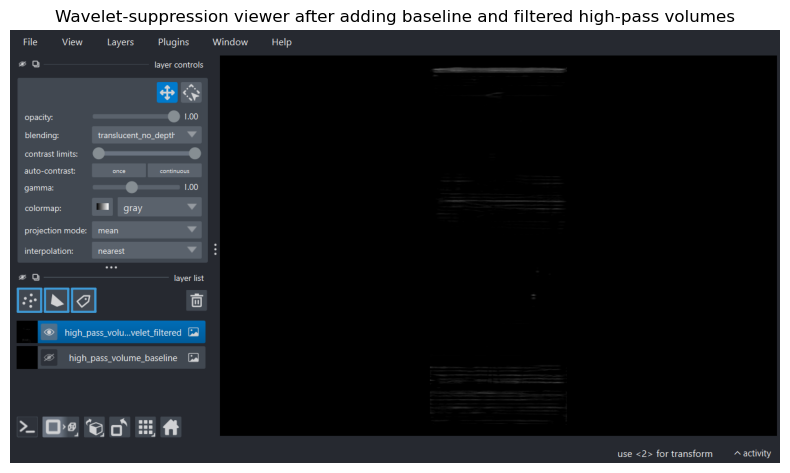

Wavelet-suppression viewer after adding baseline and filtered FFT log-magnitude volumes


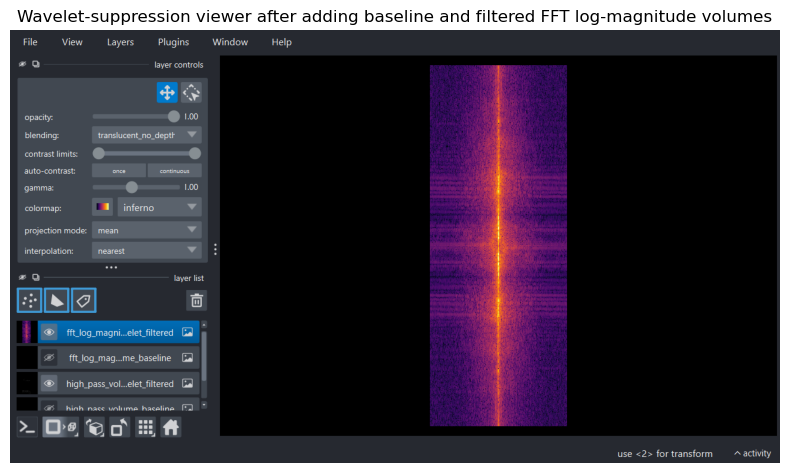

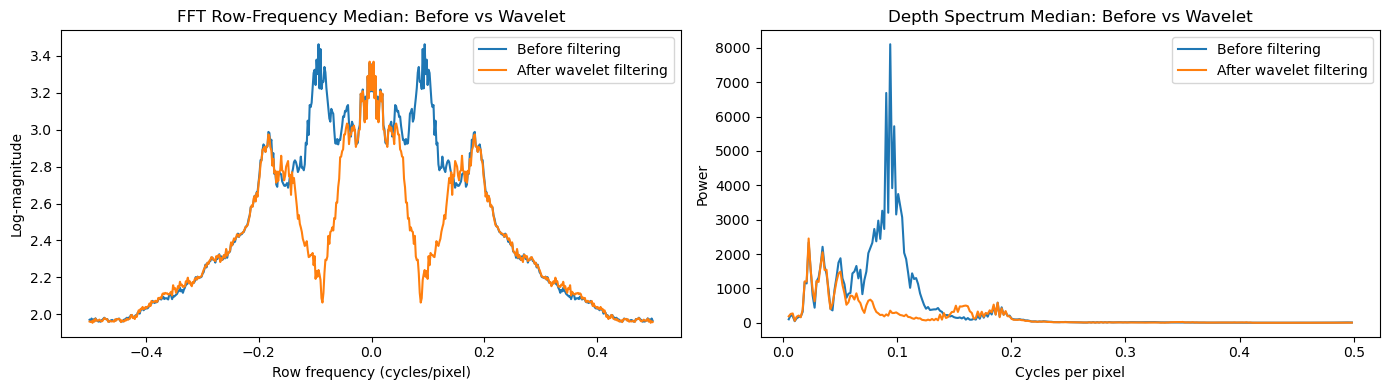

Wavelet detail level removed: 3 (index 4 in coeff list)
Estimated A-line spacing after wavelet filtering: median=28.70 px, IQR=(21.26, 33.76) px


In [12]:
wavelet_filter_name = 'db4'
wavelet_object = pywt.Wavelet(wavelet_filter_name)
max_decomposition_level = pywt.dwt_max_level(image_height, wavelet_object.dec_len)

target_period_pixels = float(spacing_median)
target_detail_level = int(np.clip(np.round(np.log2(target_period_pixels)), 1, max_decomposition_level))
target_detail_index = max_decomposition_level - target_detail_level + 1

wavelet_filtered_high_pass_volume = np.empty_like(high_pass_volume, dtype=np.float32)
for plane_index in range(plane_count):
    plane = high_pass_volume[plane_index]
    reconstructed_plane = np.empty_like(plane, dtype=np.float32)
    for column_index in range(image_width):
        depth_signal = plane[:, column_index]
        coefficients = pywt.wavedec(
            depth_signal,
            wavelet_filter_name,
            mode='symmetric',
            level=max_decomposition_level,
        )
        coefficients[target_detail_index] = np.zeros_like(coefficients[target_detail_index])
        reconstructed_signal = pywt.waverec(coefficients, wavelet_filter_name, mode='symmetric')
        reconstructed_plane[:, column_index] = reconstructed_signal[:image_height]
    wavelet_filtered_high_pass_volume[plane_index] = reconstructed_plane

wavelet_filtered_fft_volume = np.fft.fftshift(
    np.fft.fft2(wavelet_filtered_high_pass_volume, axes=(1, 2)),
    axes=(1, 2),
)
wavelet_filtered_fft_log_magnitude_volume = np.log1p(np.abs(wavelet_filtered_fft_volume))

viewer_wavelet_filter = napari.Viewer(title='Wavelet Suppression QC')
viewer_wavelet_filter.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume_baseline', colormap='gray', visible=False)
viewer_wavelet_filter.add_image(wavelet_filtered_high_pass_volume, contrast_limits=[0, wavelet_filtered_high_pass_volume.max()], name='high_pass_volume_wavelet_filtered', colormap='gray')
capture_napari_screenshot(viewer_wavelet_filter, 'Wavelet-suppression viewer after adding baseline and filtered high-pass volumes')
viewer_wavelet_filter.add_image(fft_log_magnitude_volume, name='fft_log_magnitude_volume_baseline', colormap='inferno', visible=False)
viewer_wavelet_filter.add_image(
    wavelet_filtered_fft_log_magnitude_volume,
    name='fft_log_magnitude_volume_wavelet_filtered',
    colormap='inferno',
)
capture_napari_screenshot(viewer_wavelet_filter, 'Wavelet-suppression viewer after adding baseline and filtered FFT log-magnitude volumes')

wavelet_filtered_depth_results_by_plane = [
    compute_depth_profile_outputs(filtered_plane, column_start_index, column_end_index)
    for filtered_plane in wavelet_filtered_high_pass_volume
]
wavelet_filtered_power_spectrum_by_plane = np.stack(
    [result[2] for result in wavelet_filtered_depth_results_by_plane],
    axis=0,
)
wavelet_filtered_valid_power_spectrum_by_plane = wavelet_filtered_power_spectrum_by_plane[:, valid_frequency_mask]
wavelet_filtered_peak_index_by_plane = np.argmax(wavelet_filtered_valid_power_spectrum_by_plane, axis=1)
wavelet_filtered_peak_frequency_by_plane = valid_frequency_axis[wavelet_filtered_peak_index_by_plane]
wavelet_filtered_spacing_by_plane = np.divide(
    1.0,
    wavelet_filtered_peak_frequency_by_plane,
    out=np.full_like(wavelet_filtered_peak_frequency_by_plane, np.nan, dtype=np.float64),
    where=wavelet_filtered_peak_frequency_by_plane > 0,
)
wavelet_filtered_spacing_median, wavelet_filtered_spacing_percentile_25, wavelet_filtered_spacing_percentile_75 = summarize_iqr(
    wavelet_filtered_spacing_by_plane, axis=0
)

wavelet_fft_row_profile_after = np.median(wavelet_filtered_fft_log_magnitude_volume, axis=2)
wavelet_fft_row_after_median, wavelet_fft_row_after_percentile_25, wavelet_fft_row_after_percentile_75 = summarize_iqr(
    wavelet_fft_row_profile_after, axis=0
)

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(row_frequency_axis, fft_row_before_median, label='Before filtering')
axis_array[0].plot(row_frequency_axis, wavelet_fft_row_after_median, label='After wavelet filtering')
axis_array[0].set_title('FFT Row-Frequency Median: Before vs Wavelet')
axis_array[0].set_xlabel('Row frequency (cycles/pixel)')
axis_array[0].set_ylabel('Log-magnitude')
axis_array[0].legend()

power_spectrum_wavelet_after_median, _, _ = summarize_iqr(
    wavelet_filtered_valid_power_spectrum_by_plane, axis=0
)
axis_array[1].plot(valid_frequency_axis, power_spectrum_before_median, label='Before filtering')
axis_array[1].plot(valid_frequency_axis, power_spectrum_wavelet_after_median, label='After wavelet filtering')
axis_array[1].set_title('Depth Spectrum Median: Before vs Wavelet')
axis_array[1].set_xlabel('Cycles per pixel')
axis_array[1].set_ylabel('Power')
axis_array[1].legend()
plt.tight_layout()
plt.show()

print(
    f'Wavelet detail level removed: {target_detail_level} (index {target_detail_index} in coeff list)'
)
print(
    'Estimated A-line spacing after wavelet filtering: '
    f'median={wavelet_filtered_spacing_median:.2f} px, '
    f'IQR=({wavelet_filtered_spacing_percentile_25:.2f}, {wavelet_filtered_spacing_percentile_75:.2f}) px'
 )

## 9) Next Step 1: Soft Notch Filtering (Gaussian Taper)

This section replaces the hard binary notch with a smooth Gaussian attenuation around the target reverberation frequency.

The objective is to reduce ringing and preserve nearby spectral content better than a hard cutoff.

Soft-notch viewer after adding baseline and filtered high-pass volumes


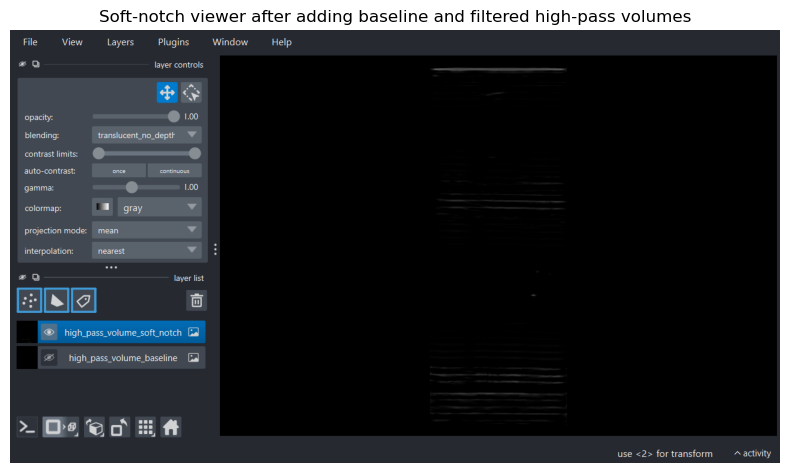

Soft-notch viewer after adding baseline and filtered FFT log-magnitude volumes


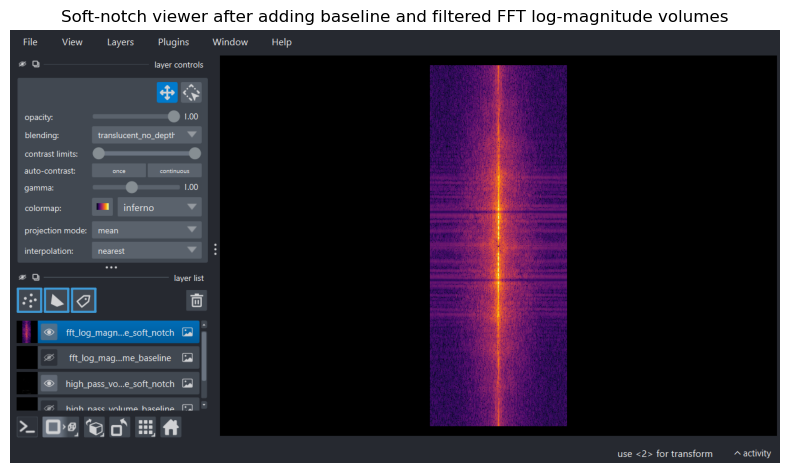

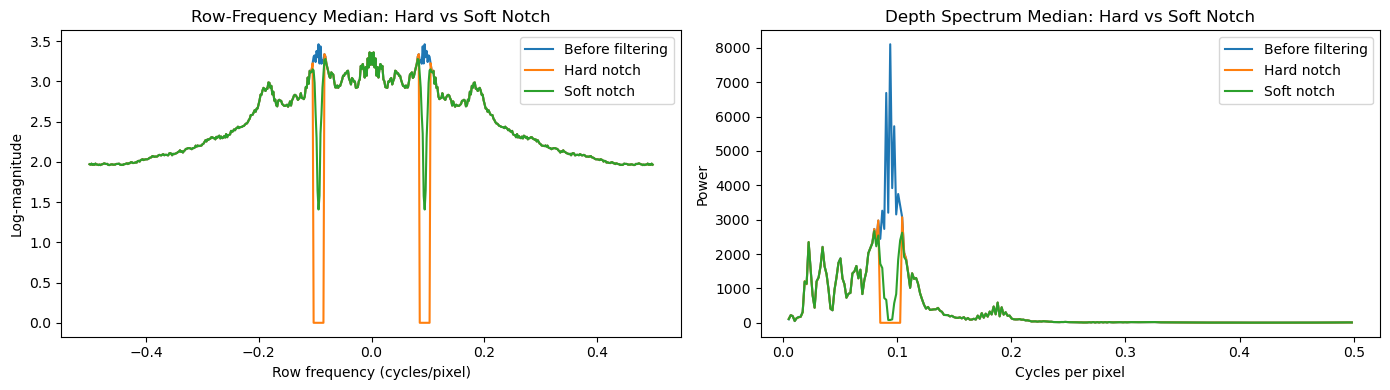

Estimated A-line spacing after soft notch: median=11.96 px, IQR=(9.57, 12.48) px


In [13]:
soft_notch_strength = 0.9
soft_notch_sigma_cycles_per_pixel = max(0.003, 0.5 * notch_half_width_cycles_per_pixel)

absolute_row_frequency = np.abs(row_frequency_axis)
distance_to_peak = absolute_row_frequency - peak_frequency_median
soft_notch_profile = 1.0 - soft_notch_strength * np.exp(
    -(distance_to_peak**2) / (2.0 * soft_notch_sigma_cycles_per_pixel**2)
)
soft_notch_profile = np.clip(soft_notch_profile, 0.05, 1.0)
soft_notch_filter_2d = soft_notch_profile[:, None].astype(np.float32)

soft_notch_fft_volume = fft_volume * soft_notch_filter_2d[None, :, :]
soft_notch_high_pass_volume = np.fft.ifft2(
    np.fft.ifftshift(soft_notch_fft_volume, axes=(1, 2)),
    axes=(1, 2),
).real
soft_notch_fft_log_magnitude_volume = np.log1p(np.abs(soft_notch_fft_volume))

viewer_soft_notch = napari.Viewer(title='Soft Notch QC')
viewer_soft_notch.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume_baseline', colormap='gray', visible=False)
viewer_soft_notch.add_image(soft_notch_high_pass_volume, contrast_limits=[0, soft_notch_high_pass_volume.max()], name='high_pass_volume_soft_notch', colormap='gray')
capture_napari_screenshot(viewer_soft_notch, 'Soft-notch viewer after adding baseline and filtered high-pass volumes')
viewer_soft_notch.add_image(fft_log_magnitude_volume, name='fft_log_magnitude_volume_baseline', colormap='inferno', visible=False)
viewer_soft_notch.add_image(
    soft_notch_fft_log_magnitude_volume,
    name='fft_log_magnitude_volume_soft_notch',
    colormap='inferno',
)
capture_napari_screenshot(viewer_soft_notch, 'Soft-notch viewer after adding baseline and filtered FFT log-magnitude volumes')

soft_notch_depth_results_by_plane = [
    compute_depth_profile_outputs(filtered_plane, column_start_index, column_end_index)
    for filtered_plane in soft_notch_high_pass_volume
]
soft_notch_power_spectrum_by_plane = np.stack([result[2] for result in soft_notch_depth_results_by_plane], axis=0)
soft_notch_valid_power_spectrum_by_plane = soft_notch_power_spectrum_by_plane[:, valid_frequency_mask]
soft_notch_peak_index_by_plane = np.argmax(soft_notch_valid_power_spectrum_by_plane, axis=1)
soft_notch_peak_frequency_by_plane = valid_frequency_axis[soft_notch_peak_index_by_plane]
soft_notch_spacing_by_plane = np.divide(
    1.0,
    soft_notch_peak_frequency_by_plane,
    out=np.full_like(soft_notch_peak_frequency_by_plane, np.nan, dtype=np.float64),
    where=soft_notch_peak_frequency_by_plane > 0,
)
soft_notch_spacing_median, soft_notch_spacing_percentile_25, soft_notch_spacing_percentile_75 = summarize_iqr(
    soft_notch_spacing_by_plane, axis=0
)

soft_notch_fft_row_profile_after = np.median(soft_notch_fft_log_magnitude_volume, axis=2)
soft_notch_fft_row_after_median, _, _ = summarize_iqr(soft_notch_fft_row_profile_after, axis=0)

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(row_frequency_axis, fft_row_before_median, label='Before filtering')
axis_array[0].plot(row_frequency_axis, fft_row_after_median, label='Hard notch')
axis_array[0].plot(row_frequency_axis, soft_notch_fft_row_after_median, label='Soft notch')
axis_array[0].set_title('Row-Frequency Median: Hard vs Soft Notch')
axis_array[0].set_xlabel('Row frequency (cycles/pixel)')
axis_array[0].set_ylabel('Log-magnitude')
axis_array[0].legend()

soft_notch_power_spectrum_median, _, _ = summarize_iqr(soft_notch_valid_power_spectrum_by_plane, axis=0)
axis_array[1].plot(valid_frequency_axis, power_spectrum_before_median, label='Before filtering')
axis_array[1].plot(valid_frequency_axis, power_spectrum_after_median, label='Hard notch')
axis_array[1].plot(valid_frequency_axis, soft_notch_power_spectrum_median, label='Soft notch')
axis_array[1].set_title('Depth Spectrum Median: Hard vs Soft Notch')
axis_array[1].set_xlabel('Cycles per pixel')
axis_array[1].set_ylabel('Power')
axis_array[1].legend()
plt.tight_layout()
plt.show()

print(
    'Estimated A-line spacing after soft notch: '
    f'median={soft_notch_spacing_median:.2f} px, '
    f'IQR=({soft_notch_spacing_percentile_25:.2f}, {soft_notch_spacing_percentile_75:.2f}) px'
 )

## 10) Next Step 2: Quantify Artifact-Mask Fraction Before/After

This section compares the fraction of voxels flagged by the same heuristic artifact mask across methods.

A decrease in flagged fraction suggests suppression of reverberation-like bands under the same thresholding rule.

Artifact-mask voxel fractions (lower is generally better for suppression):
  baseline: 0.0554
hard_notch: 0.0535
soft_notch: 0.0515
   wavelet: 0.0535


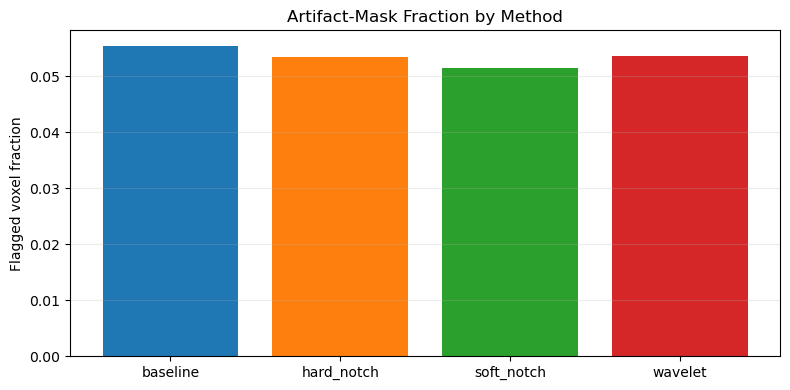

In [14]:
def compute_artifact_mask_fraction(input_high_pass_volume):
    band_energy = input_high_pass_volume[:, :, column_start_index:column_end_index].mean(axis=2)
    threshold = band_energy.mean(axis=1, keepdims=True) + 1.2 * band_energy.std(axis=1, keepdims=True)
    row_mask = band_energy > threshold
    mask_volume = np.broadcast_to(row_mask[:, :, None], volume.shape)
    mask_volume = ndimage.binary_opening(
        mask_volume,
        structure=np.ones((1, 1, 9), dtype=bool),
    )
    return mask_volume.mean()

artifact_fraction_by_method = {
    'baseline': compute_artifact_mask_fraction(high_pass_volume),
    'hard_notch': compute_artifact_mask_fraction(filtered_high_pass_volume),
    'soft_notch': compute_artifact_mask_fraction(soft_notch_high_pass_volume),
    'wavelet': compute_artifact_mask_fraction(wavelet_filtered_high_pass_volume),
}

print('Artifact-mask voxel fractions (lower is generally better for suppression):')
for method_name, method_fraction in artifact_fraction_by_method.items():
    print(f'{method_name:>10s}: {method_fraction:.4f}')

figure, axis = plt.subplots(1, 1, figsize=(8, 4))
method_names = list(artifact_fraction_by_method.keys())
method_values = [artifact_fraction_by_method[name] for name in method_names]
axis.bar(method_names, method_values, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
axis.set_title('Artifact-Mask Fraction by Method')
axis.set_ylabel('Flagged voxel fraction')
axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 11) Next Step 3: Structure-Preservation Metrics

This section quantifies how much each filtering method preserves structure relative to the baseline high-pass volume.

Reported metrics:
- Correlation with baseline (higher is better).
- Normalized RMSE (lower is better).
- Gradient-energy ratio relative to baseline (closer to 1.0 is better).

Structure-preservation metrics (relative to baseline high-pass volume):
     method | correlation | normalized_rmse | gradient_energy_ratio
hard_notch |      0.8153 |          0.5791 |                0.6623
soft_notch |      0.9313 |          0.3722 |                0.7259
   wavelet |      0.7147 |          0.7012 |                0.4737


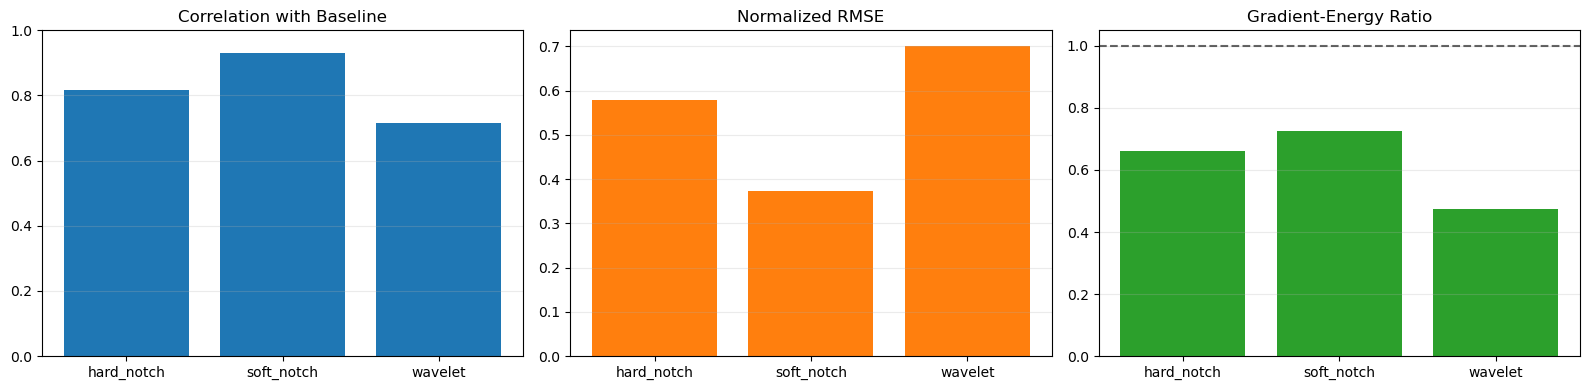

In [15]:
def compute_structure_metrics(reference_volume, candidate_volume):
    reference_flat = reference_volume.ravel()
    candidate_flat = candidate_volume.ravel()

    reference_mean = reference_flat.mean()
    candidate_mean = candidate_flat.mean()
    reference_centered = reference_flat - reference_mean
    candidate_centered = candidate_flat - candidate_mean

    correlation = np.dot(reference_centered, candidate_centered) / (
        np.linalg.norm(reference_centered) * np.linalg.norm(candidate_centered) + 1e-8
    )
    normalized_rmse = np.sqrt(np.mean((candidate_flat - reference_flat) ** 2)) / (reference_flat.std() + 1e-8)

    reference_gradient_y, reference_gradient_x = np.gradient(reference_volume, axis=(1, 2))
    candidate_gradient_y, candidate_gradient_x = np.gradient(candidate_volume, axis=(1, 2))
    reference_gradient_energy = np.mean(reference_gradient_y**2 + reference_gradient_x**2)
    candidate_gradient_energy = np.mean(candidate_gradient_y**2 + candidate_gradient_x**2)
    gradient_energy_ratio = candidate_gradient_energy / (reference_gradient_energy + 1e-8)

    return correlation, normalized_rmse, gradient_energy_ratio

structure_metrics_by_method = {
    'hard_notch': compute_structure_metrics(high_pass_volume, filtered_high_pass_volume),
    'soft_notch': compute_structure_metrics(high_pass_volume, soft_notch_high_pass_volume),
    'wavelet': compute_structure_metrics(high_pass_volume, wavelet_filtered_high_pass_volume),
}

print('Structure-preservation metrics (relative to baseline high-pass volume):')
print('     method | correlation | normalized_rmse | gradient_energy_ratio')
for method_name, metric_values in structure_metrics_by_method.items():
    correlation, normalized_rmse, gradient_energy_ratio = metric_values
    print(
        f'{method_name:>10s} | {correlation:11.4f} | {normalized_rmse:15.4f} | {gradient_energy_ratio:21.4f}'
    )

method_names = list(structure_metrics_by_method.keys())
correlation_values = [structure_metrics_by_method[name][0] for name in method_names]
rmse_values = [structure_metrics_by_method[name][1] for name in method_names]
gradient_ratio_values = [structure_metrics_by_method[name][2] for name in method_names]

figure, axis_array = plt.subplots(1, 3, figsize=(16, 4))
axis_array[0].bar(method_names, correlation_values, color='tab:blue')
axis_array[0].set_title('Correlation with Baseline')
axis_array[0].set_ylim(0.0, 1.0)
axis_array[0].grid(axis='y', alpha=0.25)

axis_array[1].bar(method_names, rmse_values, color='tab:orange')
axis_array[1].set_title('Normalized RMSE')
axis_array[1].grid(axis='y', alpha=0.25)

axis_array[2].bar(method_names, gradient_ratio_values, color='tab:green')
axis_array[2].set_title('Gradient-Energy Ratio')
axis_array[2].axhline(1.0, linestyle='--', color='k', alpha=0.6)
axis_array[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## 12) Wavelet-Based Reverberation Suppression (Synthetic A-line Demo)

### Physics background

An ultrasound A-line measured in the presence of high-impedance reflectors
can be modelled as

$$
s(t) = \sum_{i} a_i \cdot p(t - \tau_i)
      + \sum_{j,k} r_{j,k} \cdot p\!\left(t - \tau_j - k\,\Delta\tau_j\right)
$$

where $p(t)$ is the transducer pulse, $\tau_i$ are the true round-trip
delays of genuine reflectors, and the double sum represents the *reverberation
train*: periodic ghost echoes at multiples $k\,\Delta\tau_j$ past each
strong reflector ($\Delta\tau_j = \tau_j$ for a simple flat reflector).

### Why wavelets?

* **Symlets (sym8)** are the closest orthogonal-wavelet match to a
  Gaussian-modulated sinusoid -- the canonical ultrasound pulse shape -- so
  each genuine reflector produces a *single, compact* cluster of large
  coefficients at the correct depth.
* A **Stationary (a-trous) Wavelet Transform (SWT)** is used instead of
  the standard DWT because it is *shift-invariant*: DWT decimation would
  shift peak positions between levels, making periodic detection unreliable.
* Reverberations are *periodic* in the SWT coefficient domain with the same
  period at every scale because SWT preserves the full sample count.

### Algorithm: Coefficient Correlation Suppression

1. Compute the SWT to $L = 6$ levels.
2. At each detail level $\ell$, locate *primary-peak* positions
   $p_0$ where $|c_\ell[p_0]| > \mu + \sigma_{\text{thr}}\cdot\sigma$
   (data-adaptive threshold).
3. Predict reverberation positions $p_0 + m\,\Delta k$ with
   $\Delta k = \lfloor \Delta\tau \cdot f_s \rceil$, $m = 1, 2, \ldots$
4. Apply a soft suppression window centred on each predicted site:
   $c_\ell[p_0 + m\,\Delta k \pm w] \leftarrow
    g(m)\,c_\ell[p_0 + m\,\Delta k \pm w]$,
   where $g(m) = 1 - \alpha\,e^{-\beta(m-1)}$ decreases with order
   to reduce the risk of distorting genuine weak reflectors.
5. Reconstruct via the inverse SWT.

> **Note on the homomorphic approach.** For multiplicative gain fields
> (frequency-dependent tissue attenuation), one could log-transform the
> *envelope* to convert the problem into an additive one before decomposing.
> Here the reverberations are already additive (linear superposition) and the
> SWT coefficients are signed, so we work directly in the wavelet domain
> without a log-transform.


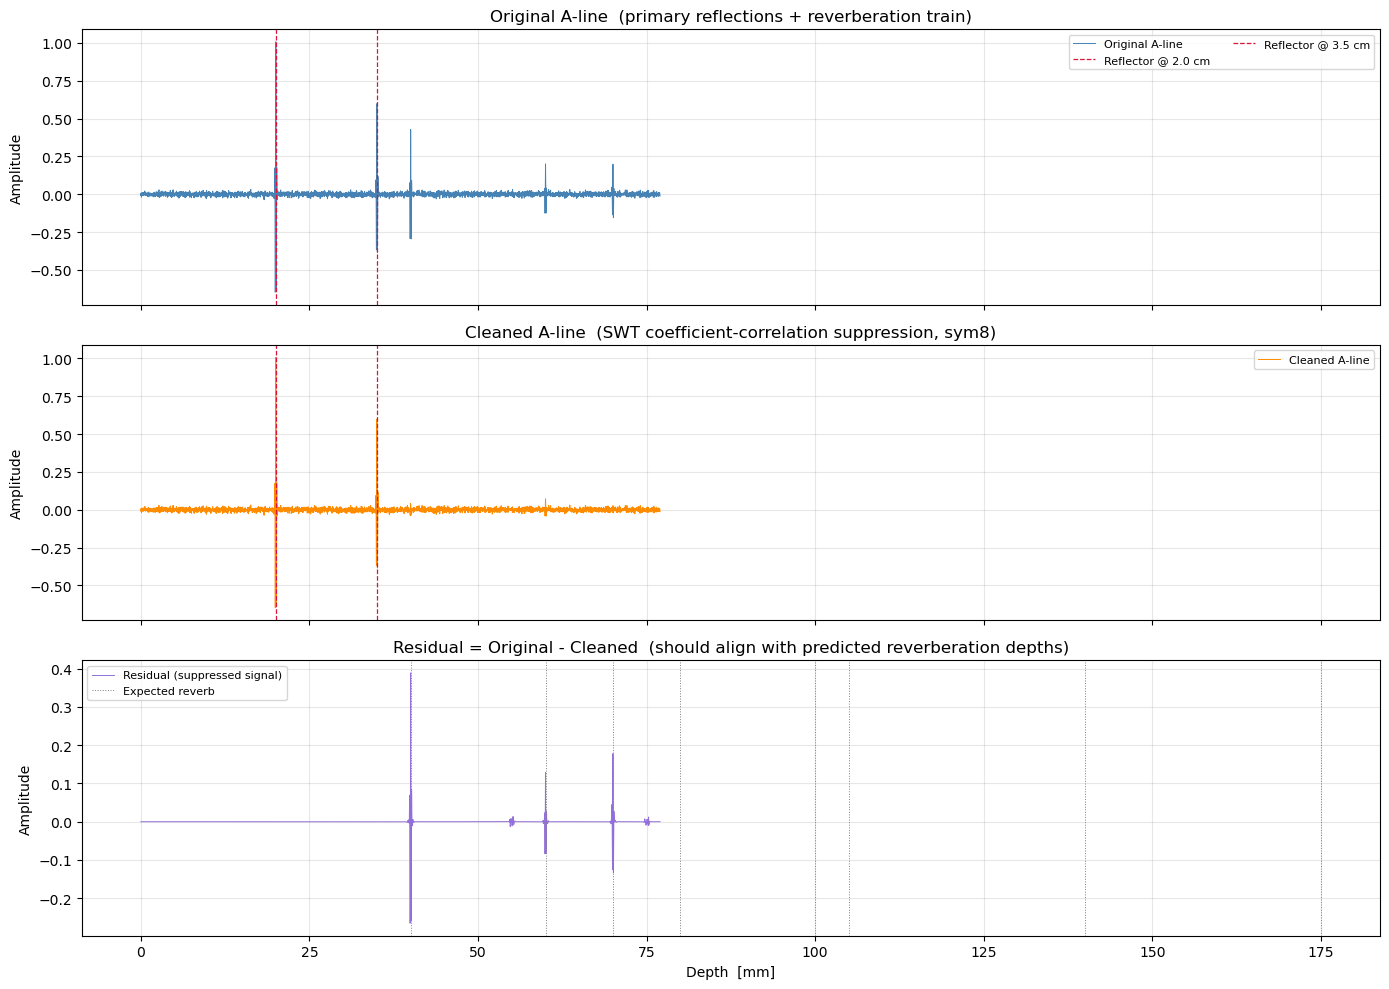

--------------------------------------------------------------
Location                             Original    Cleaned  Reduction
--------------------------------------------------------------
Primary  @ 2.0 cm                      3.7689     3.7689       0.0%
  Reverb k=1 @ 40.0 mm                 0.7533     0.0138      98.2%
  Reverb k=2 @ 60.0 mm                 0.1498     0.0222      85.2%
Primary  @ 3.5 cm                      1.3494     1.3494       0.0%
  Reverb k=1 @ 70.0 mm                 0.1802     0.0090      95.0%
--------------------------------------------------------------


In [16]:
# =============================================================================
# Section 12 - Wavelet-Based Reverberation Suppression
# Physics-to-math mapping and 'Coefficient Correlation' method
# =============================================================================

import numpy as np
import pywt
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# -- 1. SYNTHETIC A-LINE ------------------------------------------------------
# Signal model:
#   s(t) = sum_i a_i * p(t-tau_i)  +  sum_{j,k} r_{j,k} * p(t-tau_j-k*dtau_j)

FS      = 40e6      # sampling frequency [Hz]  (40 MHz typical for medical US)
C_SOUND = 1540.0   # speed of sound in soft tissue [m/s]
DURATION = 100e-6  # record length [s]  => ~7.7 cm depth range
N        = int(FS * DURATION)
t_axis   = np.arange(N) / FS
depth_mm = t_axis * C_SOUND / 2.0 * 1e3   # two-way time -> depth [mm]

F0    = 5e6          # pulse centre frequency [Hz]
BW    = 3e6          # -6 dB bandwidth [Hz]
SIGMA = 1.0 / (np.pi * BW)   # Gaussian envelope width [s]


def modulated_pulse(t, t0, amplitude=1.0):
    # Gaussian-modulated sinusoid - canonical US pulse  p(t - t0)
    env = np.exp(-0.5 * ((t - t0) / SIGMA) ** 2)
    return amplitude * env * np.cos(2 * np.pi * F0 * (t - t0))


# Two high-impedance objects:  (depth [m], amplitude, decay per bounce)
OBJECTS = [
    dict(depth=0.020, amp=1.00, decay=0.45),   # Object 1 at 2.0 cm
    dict(depth=0.035, amp=0.60, decay=0.35),   # Object 2 at 3.5 cm
]
N_REVERB = 4   # number of reverberation orders per object

aline = np.zeros(N, dtype=np.float64)
for obj in OBJECTS:
    tau = 2.0 * obj['depth'] / C_SOUND   # round-trip delay [s]
    # Primary reflection (k=0 in the signal model)
    aline += modulated_pulse(t_axis, tau, amplitude=obj['amp'])
    # Reverberation train: echoes at tau + k*delta_tau, delta_tau = tau
    for k in range(1, N_REVERB + 1):
        r_amp = obj['amp'] * (obj['decay'] ** k)
        aline += modulated_pulse(t_axis, tau + k * tau, amplitude=r_amp)

# White Gaussian noise (SNR ~ 20 dB)
aline += rng.normal(scale=0.01, size=N)

# -- 2. STATIONARY WAVELET TRANSFORM (SWT) ------------------------------------
# sym8 closely matches the Gaussian-modulated US pulse, giving compact and
# well-localised coefficients per reflector.
# SWT is shift-invariant (no decimation), so peak sample indices map
# directly to physical depths without inter-level translation artefacts.

WAVELET  = 'sym8'
N_LEVELS = 5

# swt() returns [(cA_1, cD_1), ..., (cA_L, cD_L)], index 0 = finest scale.
swt_coeffs  = pywt.swt(aline, WAVELET, level=N_LEVELS, norm=False)
detail_list = [cD for (_, cD) in swt_coeffs]   # detail bands
approx_list = [cA for (cA, _) in swt_coeffs]   # approximation bands

# -- 3. COEFFICIENT CORRELATION SUPPRESSION -----------------------------------
# For each primary-peak position p0 detected in a detail band, reverberation
# positions are p0 + m * delta_k  (m = 1, 2, ...) where
#   delta_k = round(delta_tau * FS).
# Because SWT preserves the full sample count at every level, delta_k is
# scale-independent -- the same integer shift applies everywhere.


def suppress_reverb_in_band(cD, delta_k, n_orders=N_REVERB + 2,
                             thresh_sigma=2.5, strength=0.90,
                             pulse_half_win=None):
    # Suppress periodic reverberation coefficients in one SWT detail band.
    #
    # Parameters
    # ----------
    # cD           : (N,) detail coefficients at one scale
    # delta_k      : int  reverberation period in samples (= round(delta_tau*FS))
    # n_orders     : int  number of reverberation orders to hunt
    # thresh_sigma : float  threshold = mean + thresh_sigma * std
    # strength     : float [0,1]  max suppression gain per echo
    # pulse_half_win: int  half-width of suppression window in samples;
    #                      defaults to ~2 pulse cycles (F0, FS-dependent)
    #
    # Returns cleaned (N,) array.
    #
    # GREEDY SHALLOW-TO-DEEP CASCADE:
    #   Sort detected peaks by depth (sample index, shallow first) and
    #   maintain a boolean is_reverb mask.  Any peak that falls inside
    #   an already-tagged reverberation zone is SKIPPED instead of being
    #   treated as a new primary.  This prevents reverberations from being
    #   mis-detected as primaries and causing false suppression of real signal.
    if pulse_half_win is None:
        pulse_half_win = max(4, int(round(2.0 / F0 * FS)))  # ~2 pulse cycles

    cleaned   = cD.copy()
    energy    = np.abs(cleaned)
    threshold = energy.mean() + thresh_sigma * energy.std()

    # Detect local maxima above threshold (window = pulse_half_win)
    above = np.where(energy > threshold)[0]
    candidates = []
    for pos in above:
        lo = max(0, pos - pulse_half_win)
        hi = min(len(cD), pos + pulse_half_win + 1)
        if energy[pos] >= energy[lo:hi].max():
            candidates.append(int(pos))

    # Process shallow-to-deep; tag suppressed zones to avoid re-use as primaries
    is_reverb = np.zeros(len(cD), dtype=bool)
    candidates.sort()  # ascending sample index == shallow to deep

    for p0 in candidates:
        if is_reverb[p0]:
            continue  # already tagged as reverberation -- skip
        # p0 is a genuine primary: suppress its periodic echoes
        for m in range(1, n_orders + 1):
            center = p0 + m * delta_k
            if center >= len(cD):
                break
            # Window broadens slightly with order: later echoes are pulse-smeared
            win = pulse_half_win + m
            lo  = max(0, center - win)
            hi  = min(len(cD), center + win + 1)
            # Soft gain g(m) = 1 - alpha*exp(-beta*(m-1)):
            # Strongest at m=1 (first, largest echo); gentler for later echoes.
            gain = 1.0 - strength * np.exp(-0.3 * (m - 1))
            cleaned[lo:hi] *= gain
            is_reverb[lo:hi] = True  # mark zone -- no re-use as false primary

    return cleaned


# Reverberation periods for both objects in samples
delta_k = {
    'obj1': int(round(2.0 * OBJECTS[0]['depth'] / C_SOUND * FS)),
    'obj2': int(round(2.0 * OBJECTS[1]['depth'] / C_SOUND * FS)),
}

# Only suppress in the SWT detail levels whose frequency band overlaps
# the pulse spectrum.  For F0=5 MHz, BW=3 MHz at FS=40 MHz:
#   Level 0 detail: [10-20 MHz]  -> noise-only  -> SKIP
#   Level 1 detail: [ 5-10 MHz]  -> upper lobe  -> suppress
#   Level 2 detail: [2.5- 5 MHz] -> main energy -> suppress
#   Level 3 detail: [1.25-2.5]   -> lower lobe  -> suppress
#   Level 4 (coarsest) approx    -> low-freq trend -> SKIP
MIN_SUPPRESS_LVL = 1   # skip lvl=0 (finest, above pulse band)
MAX_SUPPRESS_LVL = N_LEVELS - 2   # skip coarsest level

cleaned_details = []
for lvl, cD in enumerate(detail_list):
    if lvl < MIN_SUPPRESS_LVL or lvl > MAX_SUPPRESS_LVL:
        cleaned_details.append(cD)
        continue
    # pulse_half_win: 2 cycles of a 5 MHz pulse at 40 MHz sampling = 16 samples
    cD_c = suppress_reverb_in_band(cD, delta_k['obj1'],
                                   pulse_half_win=int(round(2.0 / F0 * FS)))
    cD_c = suppress_reverb_in_band(cD_c, delta_k['obj2'],
                                   pulse_half_win=int(round(2.0 / F0 * FS)))
    cleaned_details.append(cD_c)

# -- 4. INVERSE SWT RECONSTRUCTION --------------------------------------------
cleaned_swt = [(approx_list[i], cleaned_details[i]) for i in range(N_LEVELS)]
aline_clean = pywt.iswt(cleaned_swt, WAVELET)

# -- 5. VISUALISATION ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(depth_mm, aline, color='steelblue', lw=0.7, label='Original A-line')
for obj in OBJECTS:
    axes[0].axvline(obj['depth'] * 1e3, color='crimson', ls='--', lw=0.9,
                    label=f"Reflector @ {obj['depth']*100:.1f} cm")
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Original A-line  (primary reflections + reverberation train)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].plot(depth_mm, aline_clean, color='darkorange', lw=0.7,
             label='Cleaned A-line')
for obj in OBJECTS:
    axes[1].axvline(obj['depth'] * 1e3, color='crimson', ls='--', lw=0.9)
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Cleaned A-line  (SWT coefficient-correlation suppression, sym8)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

residual = aline - aline_clean
axes[2].plot(depth_mm, residual, color='mediumpurple', lw=0.7,
             label='Residual (suppressed signal)')
# Mark expected reverberation depths for reference
first_reverb_labeled = False
for obj in OBJECTS:
    tau = 2.0 * obj['depth'] / C_SOUND
    for k in range(1, N_REVERB + 1):
        reverb_depth_mm = (tau + k * tau) * C_SOUND / 2.0 * 1e3
        lbl = 'Expected reverb' if not first_reverb_labeled else ''
        axes[2].axvline(reverb_depth_mm, color='gray', ls=':', lw=0.7, label=lbl)
        first_reverb_labeled = True
axes[2].set_xlabel('Depth  [mm]')
axes[2].set_ylabel('Amplitude')
axes[2].set_title('Residual = Original - Cleaned  '
                  '(should align with predicted reverberation depths)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -- 6. QUANTITATIVE METRICS --------------------------------------------------


def window_energy(sig, center_sample, half_width):
    lo = max(0, center_sample - half_width)
    hi = min(len(sig), center_sample + half_width + 1)
    return float(np.sum(sig[lo:hi] ** 2))


hw = int(round(1e-6 * FS))   # +-1 us window around each feature

print('-' * 62)
print(f"{'Location':<34}  {'Original':>9}  {'Cleaned':>9}  {'Reduction':>9}")
print('-' * 62)

for obj in OBJECTS:
    tau = 2.0 * obj['depth'] / C_SOUND
    p_samp = int(round(tau * FS))
    e_orig = window_energy(aline,       p_samp, hw)
    e_cln  = window_energy(aline_clean, p_samp, hw)
    label  = f"Primary  @ {obj['depth']*100:.1f} cm"
    print(f"{label:<34}  {e_orig:>9.4f}  {e_cln:>9.4f}  "
          f"{(1 - e_cln / max(e_orig, 1e-12)) * 100:>8.1f}%")
    for k in range(1, N_REVERB + 1):
        c_samp = int(round((tau + k * tau) * FS))
        if c_samp >= N:
            break
        e_orig = window_energy(aline,       c_samp, hw)
        e_cln  = window_energy(aline_clean, c_samp, hw)
        reverb_depth_mm = (tau + k * tau) * C_SOUND / 2.0 * 1e3
        label  = f"  Reverb k={k} @ {reverb_depth_mm:.1f} mm"
        print(f"{label:<34}  {e_orig:>9.4f}  {e_cln:>9.4f}  "
              f"{(1 - e_cln / max(e_orig, 1e-12)) * 100:>8.1f}%")

print('-' * 62)


## 13) Apply Targeted SWT Suppression to the 3D ROI Volume

### From synthetic demo to real data

Section 12 validated the algorithm on a synthetic A-line where perfect ground truth was available. Here we apply the same **Stationary Wavelet Transform (SWT) Coefficient Correlation Suppression** to every depth column of the real ROI-cropped ultrasound stack.

### Targeted change for this dataset

In this acquisition, reverberation bands are clearly visible as quasi-periodic oscillations along the y axis with period near **13 pixels**.

Instead of relying only on the global Fourier estimate, this section now:

1. Uses `target_period_px = spacing_median` as a physics-guided prior.
2. Refines the period by searching the depth autocorrelation peak in a narrow neighborhood around 13 px.
3. Applies SWT suppression with a small set of nearby candidate periods (`k-1`, `k`, `k+1`) so mild local period drift is still attenuated.

This keeps suppression focused on reverberation-like periodicity while preserving non-periodic structures better.

Targeted SWT suppression parameters:
  Wavelet          : sym8   Levels: 5
  target_period_px : 10.62962962962963
  estimated_period : 10 px
  period_candidates: [9, 10, 11]
  pulse_half_win   : 4 px
Processing 189 planes x 219 columns ...
  plane 5/189
  plane 10/189
  plane 15/189
  plane 20/189
  plane 25/189
  plane 30/189
  plane 35/189
  plane 40/189
  plane 45/189
  plane 50/189
  plane 55/189
  plane 60/189
  plane 65/189
  plane 70/189
  plane 75/189
  plane 80/189
  plane 85/189
  plane 90/189
  plane 95/189
  plane 100/189
  plane 105/189
  plane 110/189
  plane 115/189
  plane 120/189
  plane 125/189
  plane 130/189
  plane 135/189
  plane 140/189
  plane 145/189
  plane 150/189
  plane 155/189
  plane 160/189
  plane 165/189
  plane 170/189
  plane 175/189
  plane 180/189
  plane 185/189
  plane 189/189
Done.


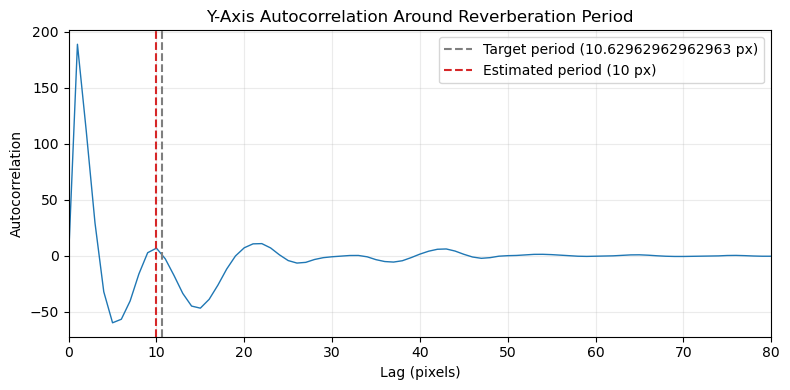

Targeted SWT viewer after adding baseline and filtered high-pass volumes


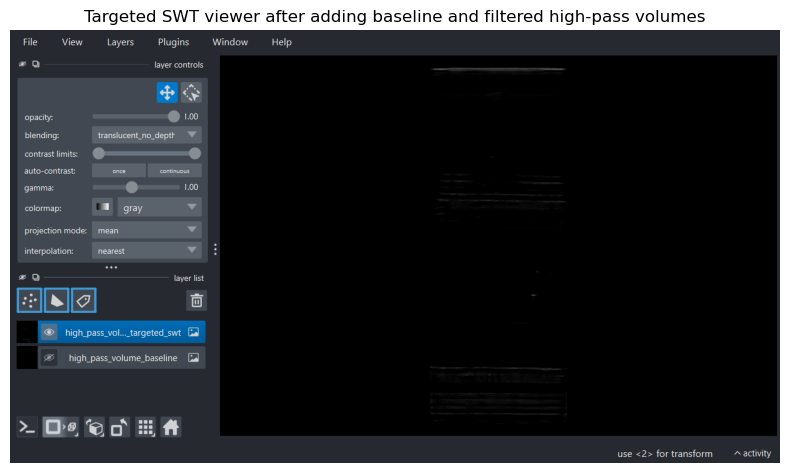

Targeted SWT viewer after adding filtered FFT log-magnitude


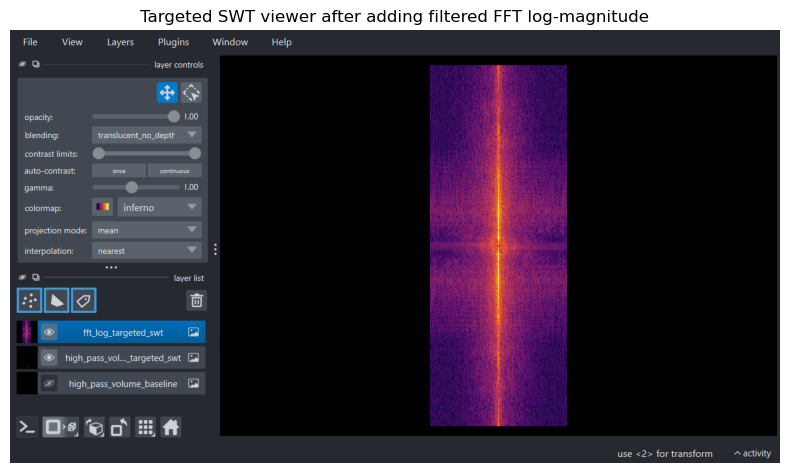

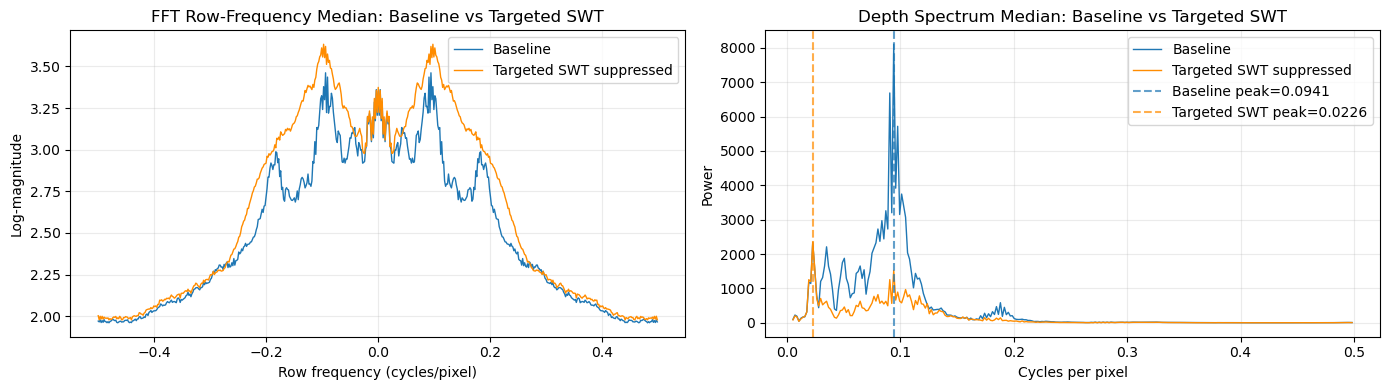

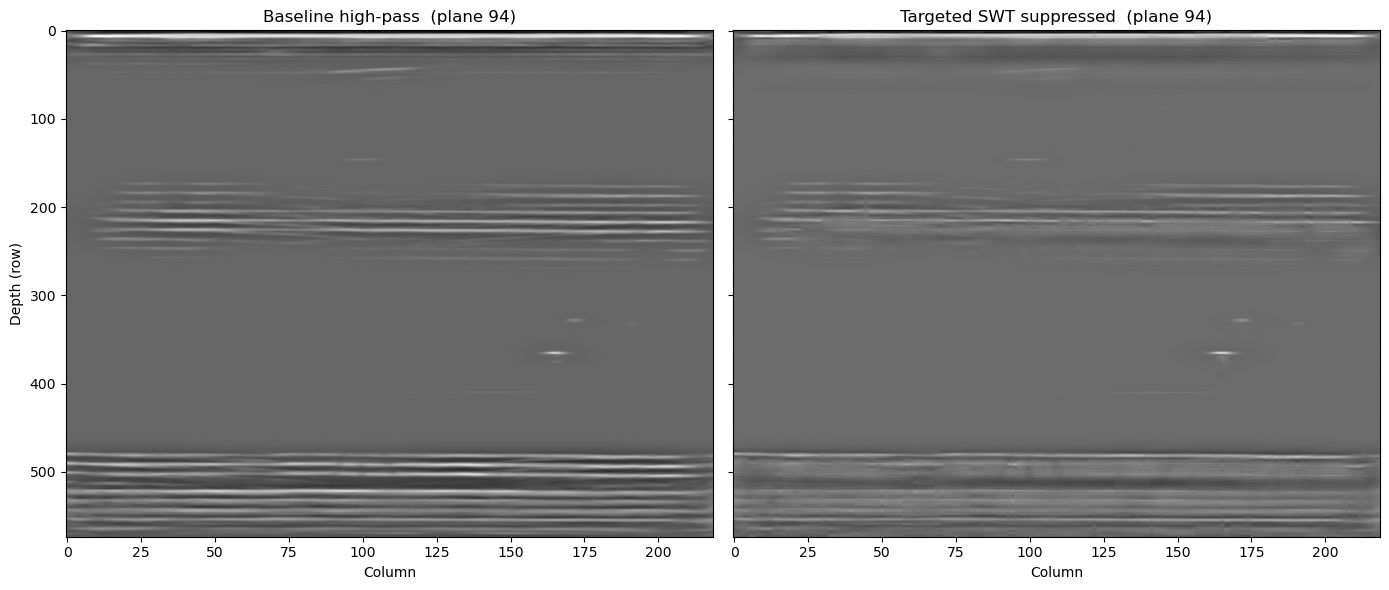

Artifact-mask voxel fractions (all methods):
    baseline: 0.0554
  hard_notch: 0.0535
  soft_notch: 0.0515
     wavelet: 0.0535
     swt_vol: 0.0493

Structure-preservation metrics (relative to baseline high-pass):
    method | correlation | norm_RMSE | grad_E_ratio
hard_notch |      0.8153 |    0.5791 |       0.6623
soft_notch |      0.9313 |    0.3722 |       0.7259
   wavelet |      0.7147 |    0.7012 |       0.4737
   swt_vol |      0.8271 |    0.6054 |       0.3580


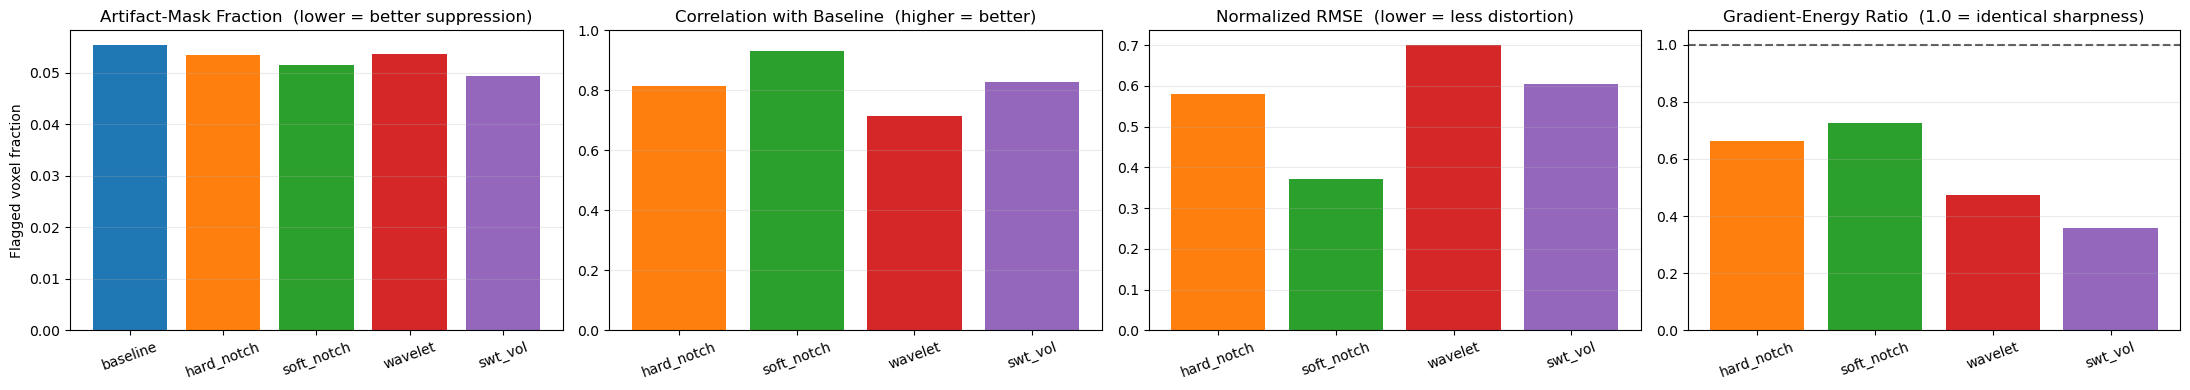

In [17]:
# =============================================================================
# Section 13 - Apply Targeted SWT Reverberation Suppression to the 3D ROI Stack
# =============================================================================

import pywt as _pywt_v   # local alias to avoid clobbering cell-28 namespace

# -- Suppression function for image A-lines -----------------------------------
# Parameterized in pixel space (no F0 / FS / C_SOUND dependency).

_SWT_WAV   = 'sym8'
_SWT_LVLS  = 5          # max SWT level for this image height and sym8
_SWT_MINL  = 1          # skip finest band (mostly noise)
_SWT_MAXL  = _SWT_LVLS - 2   # skip coarsest trend band


def _suppress_reverb_col(
    col: np.ndarray,
    delta_k: int,
    n_orders: int = 6,
    thresh_sigma: float = 2.5,
    strength: float = 0.90,
    pulse_half_win: int = 8,
) -> np.ndarray:
    """Apply SWT coefficient-correlation suppression to one depth column."""
    # SWT requires the signal length to be divisible by 2**level.
    n_orig  = len(col)
    pad_len = int(np.ceil(n_orig / 2 ** _SWT_LVLS)) * 2 ** _SWT_LVLS
    col_f64 = np.pad(col.astype(np.float64), (0, pad_len - n_orig), mode='edge')
    n       = len(col_f64)

    swt = _pywt_v.swt(col_f64, _SWT_WAV, level=_SWT_LVLS, norm=False)
    det = [cD for (_, cD) in swt]
    app = [cA for (cA, _) in swt]

    cleaned_det = []
    for lvl, cD in enumerate(det):
        if lvl < _SWT_MINL or lvl > _SWT_MAXL:
            cleaned_det.append(cD)
            continue

        c = cD.copy()
        energy = np.abs(c)
        thr = energy.mean() + thresh_sigma * energy.std()

        above = np.where(energy > thr)[0]
        candidates = []
        for pos in above:
            lo = max(0, pos - pulse_half_win)
            hi = min(n, pos + pulse_half_win + 1)
            if energy[pos] >= energy[lo:hi].max():
                candidates.append(int(pos))

        # Greedy shallow-to-deep cascade: once tagged as reverberation,
        # a position cannot become a new primary candidate.
        is_reverb = np.zeros(n, dtype=bool)
        for p0 in sorted(candidates):
            if is_reverb[p0]:
                continue
            for m in range(1, n_orders + 1):
                center = p0 + m * delta_k
                if center >= n:
                    break
                win = pulse_half_win + m
                lo = max(0, center - win)
                hi = min(n, center + win + 1)
                gain = 1.0 - strength * np.exp(-0.3 * (m - 1))
                c[lo:hi] *= gain
                is_reverb[lo:hi] = True

        cleaned_det.append(c)

    return _pywt_v.iswt(
        [(app[i], cleaned_det[i]) for i in range(_SWT_LVLS)], _SWT_WAV
    )[:n_orig].astype(np.float32)


def estimate_period_near_target(
    input_high_pass_volume: np.ndarray,
    start_col: int,
    end_col: int,
    target_period: int = 13,
    search_half_width: int = 3,
) -> tuple[int, np.ndarray, np.ndarray]:
    """Estimate a dominant y-period near a target lag from an autocorrelation profile."""
    # Build a robust y-axis profile using median over planes and selected columns.
    y_profile = np.median(input_high_pass_volume[:, :, start_col:end_col], axis=(0, 2)).astype(np.float64)
    y_profile = signal.detrend(y_profile)
    y_profile -= y_profile.mean()

    autocorr = signal.correlate(y_profile, y_profile, mode='full')
    autocorr = autocorr[len(y_profile) - 1:]
    autocorr[0] = 0.0

    lo = max(2, int(round(target_period)) - search_half_width)
    hi = min(len(autocorr) - 1, int(round(target_period)) + search_half_width)
    if lo > hi:
        return int(round(target_period)), np.arange(len(autocorr)), autocorr

    lag_axis = np.arange(len(autocorr))
    local_lags = lag_axis[lo:hi + 1]
    local_peak_lag = int(local_lags[np.argmax(autocorr[lo:hi + 1])])
    return local_peak_lag, lag_axis, autocorr


# -- Targeted period selection around the known reverberation spacing --------
target_period_px = spacing_median
estimated_period_px, lag_axis, autocorr_y = estimate_period_near_target(
    high_pass_volume, column_start_index, column_end_index, target_period=target_period_px, search_half_width=3
)

# Main period plus neighbors to tolerate slight local drift.
period_candidates = sorted({p for p in [estimated_period_px - 1, estimated_period_px, estimated_period_px + 1] if p >= 2})
period_strength = {p: (0.90 if p == estimated_period_px else 0.50) for p in period_candidates}
pulse_half_window_px = int(np.clip(round(estimated_period_px / 3.0), 4, 24))

print('Targeted SWT suppression parameters:')
print(f'  Wavelet          : {_SWT_WAV}   Levels: {_SWT_LVLS}')
print(f'  target_period_px : {target_period_px}')
print(f'  estimated_period : {estimated_period_px} px')
print(f'  period_candidates: {period_candidates}')
print(f'  pulse_half_win   : {pulse_half_window_px} px')
print(f'Processing {plane_count} planes x {image_width} columns ...')

swt_vol_filtered = np.empty_like(high_pass_volume, dtype=np.float32)
for _pi in range(plane_count):
    for _ci in range(image_width):
        col = high_pass_volume[_pi, :, _ci]
        for _period in period_candidates:
            col = _suppress_reverb_col(
                col,
                _period,
                strength=period_strength[_period],
                pulse_half_win=pulse_half_window_px,
            )
        swt_vol_filtered[_pi, :, _ci] = col
    if (_pi + 1) % 5 == 0 or _pi == plane_count - 1:
        print(f'  plane {_pi + 1}/{plane_count}')

print('Done.')

# -- Visualization of period refinement --------------------------------------
figure, axis = plt.subplots(1, 1, figsize=(8, 4))
axis.plot(lag_axis, autocorr_y, color='tab:blue', lw=1.0)
axis.axvline(target_period_px, color='tab:gray', linestyle='--', label=f'Target period ({target_period_px} px)')
axis.axvline(estimated_period_px, color='tab:red', linestyle='--', label=f'Estimated period ({estimated_period_px} px)')
axis.set_xlim(0, min(80, len(lag_axis) - 1))
axis.set_title('Y-Axis Autocorrelation Around Reverberation Period')
axis.set_xlabel('Lag (pixels)')
axis.set_ylabel('Autocorrelation')
axis.legend()
axis.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

viewer_targeted_swt = napari.Viewer(title='Targeted SWT QC')
viewer_targeted_swt.add_image(high_pass_volume, contrast_limits=[0, high_pass_volume.max()], name='high_pass_volume_baseline', colormap='gray', visible=False)
viewer_targeted_swt.add_image(swt_vol_filtered, contrast_limits=[0, swt_vol_filtered.max()], name='high_pass_volume_targeted_swt', colormap='gray')
capture_napari_screenshot(viewer_targeted_swt, 'Targeted SWT viewer after adding baseline and filtered high-pass volumes')

_swt_fft_vol = np.fft.fftshift(np.fft.fft2(swt_vol_filtered, axes=(1, 2)), axes=(1, 2))
_swt_fft_logvol = np.log1p(np.abs(_swt_fft_vol))
viewer_targeted_swt.add_image(_swt_fft_logvol, name='fft_log_targeted_swt', colormap='inferno')
capture_napari_screenshot(viewer_targeted_swt, 'Targeted SWT viewer after adding filtered FFT log-magnitude')

# -- Depth spectrum: baseline vs targeted SWT --------------------------------
_swt_depth = [
    compute_depth_profile_outputs(p, column_start_index, column_end_index)
    for p in swt_vol_filtered
]
_swt_ps_planes = np.stack([r[2] for r in _swt_depth], axis=0)
_swt_valid_ps = _swt_ps_planes[:, valid_frequency_mask]
_swt_pk_freq = valid_frequency_axis[np.argmax(_swt_valid_ps, axis=1)]
_swt_spacing = np.where(_swt_pk_freq > 0, 1.0 / _swt_pk_freq, np.nan)
_swt_sp_med, _swt_sp25, _swt_sp75 = summarize_iqr(_swt_spacing)
_swt_pk_med, _, _ = summarize_iqr(_swt_pk_freq)
_swt_ps_med, _, _ = summarize_iqr(_swt_valid_ps, axis=0)

_swt_fft_row_profile = np.median(_swt_fft_logvol, axis=2)
_swt_fft_row_med, _, _ = summarize_iqr(_swt_fft_row_profile, axis=0)

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))
axis_array[0].plot(row_frequency_axis, fft_row_before_median, lw=1.0, label='Baseline')
axis_array[0].plot(
    row_frequency_axis, _swt_fft_row_med, lw=1.0, color='darkorange', label='Targeted SWT suppressed'
 )
axis_array[0].set_title('FFT Row-Frequency Median: Baseline vs Targeted SWT')
axis_array[0].set_xlabel('Row frequency (cycles/pixel)')
axis_array[0].set_ylabel('Log-magnitude')
axis_array[0].legend()
axis_array[0].grid(True, alpha=0.25)

axis_array[1].plot(valid_frequency_axis, power_spectrum_before_median, lw=1.0, label='Baseline')
axis_array[1].plot(
    valid_frequency_axis, _swt_ps_med, lw=1.0, color='darkorange', label='Targeted SWT suppressed'
 )
axis_array[1].axvline(
    peak_frequency_median, color='tab:blue', ls='--', alpha=0.7, label=f'Baseline peak={peak_frequency_median:.4f}'
)
axis_array[1].axvline(
    _swt_pk_med, color='darkorange', ls='--', alpha=0.7, label=f'Targeted SWT peak={_swt_pk_med:.4f}'
)
axis_array[1].set_title('Depth Spectrum Median: Baseline vs Targeted SWT')
axis_array[1].set_xlabel('Cycles per pixel')
axis_array[1].set_ylabel('Power')
axis_array[1].legend()
axis_array[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -- Side-by-side image comparison (middle plane) -----------------------------
_mid = plane_count // 2
figure, axis_array = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axis_array[0].imshow(high_pass_volume[_mid], cmap='gray', aspect='auto')
axis_array[0].set_title(f'Baseline high-pass  (plane {_mid})')
axis_array[0].set_xlabel('Column')
axis_array[0].set_ylabel('Depth (row)')
axis_array[1].imshow(swt_vol_filtered[_mid], cmap='gray', aspect='auto')
axis_array[1].set_title(f'Targeted SWT suppressed  (plane {_mid})')
axis_array[1].set_xlabel('Column')
plt.tight_layout()
plt.show()

# -- Update and display all metrics ------------------------------------------
artifact_fraction_by_method['swt_vol'] = compute_artifact_mask_fraction(swt_vol_filtered)
structure_metrics_by_method['swt_vol'] = compute_structure_metrics(
    high_pass_volume, swt_vol_filtered
)

print('Artifact-mask voxel fractions (all methods):')
for _name, _frac in artifact_fraction_by_method.items():
    print(f'  {_name:>10s}: {_frac:.4f}')

print()
print('Structure-preservation metrics (relative to baseline high-pass):')
print(f'{"method":>10s} | {"correlation":>11s} | {"norm_RMSE":>9s} | {"grad_E_ratio":>12s}')
for _name, (_corr, _rmse, _grad) in structure_metrics_by_method.items():
    print(f'{_name:>10s} | {_corr:11.4f} | {_rmse:9.4f} | {_grad:12.4f}')

_all_m = list(artifact_fraction_by_method.keys())
_met_m = list(structure_metrics_by_method.keys())
_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
            'tab:purple', 'tab:brown', 'darkgreen']

figure, axis_array = plt.subplots(1, 4, figsize=(22, 4))

axis_array[0].bar(
    _all_m, [artifact_fraction_by_method[m] for m in _all_m], color=_palette[:len(_all_m)]
)
axis_array[0].set_title('Artifact-Mask Fraction  (lower = better suppression)')
axis_array[0].set_ylabel('Flagged voxel fraction')
axis_array[0].grid(axis='y', alpha=0.25)
axis_array[0].tick_params(axis='x', rotation=20)

axis_array[1].bar(
    _met_m, [structure_metrics_by_method[m][0] for m in _met_m], color=_palette[1:len(_met_m) + 1]
)
axis_array[1].set_title('Correlation with Baseline  (higher = better)')
axis_array[1].set_ylim(0.0, 1.0)
axis_array[1].grid(axis='y', alpha=0.25)
axis_array[1].tick_params(axis='x', rotation=20)

axis_array[2].bar(
    _met_m, [structure_metrics_by_method[m][1] for m in _met_m], color=_palette[1:len(_met_m) + 1]
)
axis_array[2].set_title('Normalized RMSE  (lower = less distortion)')
axis_array[2].grid(axis='y', alpha=0.25)
axis_array[2].tick_params(axis='x', rotation=20)

axis_array[3].bar(
    _met_m, [structure_metrics_by_method[m][2] for m in _met_m], color=_palette[1:len(_met_m) + 1]
)
axis_array[3].set_title('Gradient-Energy Ratio  (1.0 = identical sharpness)')
axis_array[3].axhline(1.0, linestyle='--', color='k', alpha=0.6)
axis_array[3].grid(axis='y', alpha=0.25)
axis_array[3].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 14) Multi-Harmonic Comb Notch + Row-Energy Gate (Final Cleaning Pass)

### Why the SWT cascade misses the first/top-most peak

The targeted SWT suppression (Section 13) works with a **greedy shallow-to-deep cascade**: it detects peaks above an adaptive threshold and suppresses their periodic echoes forward in depth. When the top-most reverberation band is *weaker* than the next one, it can either:
- be treated as a "primary" reflector (so it is never tagged as an echo), or
- fall below the adaptive threshold and be skipped entirely.

Either way the cascade leaves the first band largely intact.

### Method: multi-harmonic Gaussian-tapered Fourier comb + row-energy sigmoid gate

This section applies two complementary steps to `swt_vol_filtered`:

1. **Multi-harmonic comb notch in the row-frequency domain.**
   The reverberation signature is periodic along y with fundamental period T0 ~13 px (confirmed by autocorrelation in Section 13). Its spectrum consists of a comb at f0=1/T0, 2*f0, 3*f0, ... up to the Nyquist limit. A smooth Gaussian-tapered attenuation window centred on each harmonic suppresses *all* reverberation rows simultaneously — including the first — without relying on peak-detection order.

2. **Row-energy z-score sigmoid gate.**
   After the comb notch, any residual horizontal bands (e.g. those whose harmonic was broadened by phase drift) are attenuated further. For every frame, rows whose band-average energy is an outlier above the local median receive an additional soft-suppression weight derived from a logistic function of the z-score. The logistic shape provides a smooth transition instead of a hard cut.

In [18]:
# =============================================================================
# Section 14 - Multi-Harmonic Comb Notch + Row-Energy Sigmoid Gate
# Builds on swt_vol_filtered (Section 13); no new imports needed.
# =============================================================================

# ---------------------------------------------------------------------------
# 1. COMB PARAMETERS
#    Use the autocorrelation-refined period from Section 13.
# ---------------------------------------------------------------------------
_T0 = float(estimated_period_px)          # fundamental period [px]
_f0 = 1.0 / _T0                           # fundamental frequency [cycles/px]

# All harmonics that fit below Nyquist (0.5 cycles/px)
_harmonics = np.arange(1, int(np.floor(0.5 / _f0)) + 1)

# Notch half-width: narrow enough to preserve non-periodic content,
# wide enough to catch slight period drift across frames.
_comb_sigma = _f0 / 5.0                   # Gaussian sigma in frequency

# Row-frequency axis (same length as image_height, consistent with fft_volume)
_row_freqs = np.fft.fftshift(np.fft.fftfreq(image_height, d=1.0))

# Build smooth comb mask (1 = pass, 0 = suppress)
_comb_gain = np.ones(image_height, dtype=np.float64)
for _k in _harmonics:
    _dist = np.abs(np.abs(_row_freqs) - _k * _f0)
    _comb_gain *= 1.0 - 0.97 * np.exp(-0.5 * (_dist / _comb_sigma) ** 2)

_comb_gain_2d = _comb_gain[:, np.newaxis]   # broadcast over columns

print('Comb notch parameters:')
print(f'  T0 = {_T0:.1f} px   f0 = {_f0:.4f} cyc/px')
print(f'  Harmonics targeted: {[int(k) for k in _harmonics]} (sigma={_comb_sigma:.5f} cyc/px)')
print(f'  Minimum gain in comb mask: {_comb_gain.min():.4f}')

# ---------------------------------------------------------------------------
# 2. APPLY COMB NOTCH TO SWT-FILTERED VOLUME
#    Each plane is FFT'd, multiplied by the comb mask, then IFFT'd.
# ---------------------------------------------------------------------------
comb_filtered_vol = np.empty_like(swt_vol_filtered, dtype=np.float32)
for _pi in range(plane_count):
    _pf = np.fft.fftshift(np.fft.fft2(swt_vol_filtered[_pi].astype(np.float64)))
    _pf *= _comb_gain_2d
    comb_filtered_vol[_pi] = np.fft.ifft2(np.fft.ifftshift(_pf)).real.astype(np.float32)

print(f'Comb notch applied to {plane_count} planes.')

# ---------------------------------------------------------------------------
# 3. ROW-ENERGY SIGMOID GATE
#    For each frame, compute per-row band energy over the central columns.
#    Rows with z-score above a threshold are soft-suppressed with a logistic.
#    This catches residual bands (including the first/shallow one) that the
#    comb may not have fully attenuated due to phase offset or period jitter.
# ---------------------------------------------------------------------------
_gate_z_threshold = 1.2    # z-score above which suppression starts (tune if needed)
_gate_steepness   = 4.0    # logistic steepness (higher = sharper transition)
_gate_max_supp    = 0.85   # maximum fraction of energy removed at strongest bands

_row_energy_raw = comb_filtered_vol[:, :, column_start_index:column_end_index].mean(axis=2)

# Robust z-score per frame using median and IQR to avoid outlier-inflates-std.
_row_med  = np.median(_row_energy_raw, axis=1, keepdims=True)
_row_iqr  = (np.percentile(_row_energy_raw, 75, axis=1, keepdims=True)
             - np.percentile(_row_energy_raw, 25, axis=1, keepdims=True)) + 1e-8
_row_z    = (_row_energy_raw - _row_med) / (_row_iqr * 1.4826)  # 1.4826 ≈ 1/Φ⁻¹(0.75)

# Overflow-safe sigmoid: exp(min(x,0)) / (exp(min(x,0)) + exp(-max(x,0)))
# This never passes a positive argument to exp, so it never overflows.
_gate_x = np.clip(_gate_steepness * (_row_z - _gate_z_threshold), -500.0, 500.0)
_ex = np.exp(np.minimum(_gate_x, 0.0))
_sigmoid = _ex / (_ex + np.exp(-np.maximum(_gate_x, 0.0)))
_supp_weight = np.clip(1.0 - _gate_max_supp * _sigmoid, 1.0 - _gate_max_supp, 1.0).astype(np.float32)

# Apply row-wise gate (broadcast over columns)
final_cleaned_vol = comb_filtered_vol * _supp_weight[:, :, np.newaxis]

print('Row-energy sigmoid gate applied.')
print(f'  z-threshold={_gate_z_threshold}, steepness={_gate_steepness}, max_suppression={_gate_max_supp}')
print(f'  Rows with gate weight < 0.95: {(_supp_weight < 0.95).sum()} / {_supp_weight.size}')

# ---------------------------------------------------------------------------
# 4. COMPARE DEPTH POWER SPECTRA: three stages
# ---------------------------------------------------------------------------
_stages = {
    'high_pass':     high_pass_volume,
    'swt_filtered':  swt_vol_filtered,
    'comb+gate':     final_cleaned_vol,
}

_stage_spectra = {}
for _sname, _svol in _stages.items():
    _ps_list = [
        compute_depth_profile_outputs(p, column_start_index, column_end_index)[2]
        for p in _svol
    ]
    _ps_stack = np.stack(_ps_list, axis=0)[:, valid_frequency_mask]
    _ps_med, _, _ = summarize_iqr(_ps_stack, axis=0)
    _stage_spectra[_sname] = _ps_med

viewer_comb_gate = napari.Viewer(title='Comb + Gate QC')
viewer_comb_gate.add_image(swt_vol_filtered,, contrast_limits=[0, swt_vol_filtered.max()], name='swt_filtered_baseline', colormap='gray', visible=False)
viewer_comb_gate.add_image(final_cleaned_vol, contrast_limits=[0, final_cleaned_vol.max()], name='final_comb_gate', colormap='gray')
capture_napari_screenshot(viewer_comb_gate, 'Comb+gate viewer after adding baseline and final cleaned volumes')

_flat    = final_cleaned_vol.ravel()
_clim_lo = float(np.percentile(_flat, 1.0))
_clim_hi = float(np.percentile(_flat, 99.0))
print(f'Auto contrast limits for final volume: [{_clim_lo:.4f}, {_clim_hi:.4f}]')

try:
    _flat_c  = comb_filtered_vol.ravel()
    viewer_comb_gate.add_image(
        comb_filtered_vol,
        name='comb_only',
        colormap='gray',
        contrast_limits=[0,
                         float(np.percentile(_flat_c, 99.0))],
        visible=False,
    )
except RuntimeError as _napari_err:
    print(f'Napari viewer not available ({_napari_err}). '
          'Re-run from cell 5 to reopen the viewer, then re-run this cell.')

figure, axis_array = plt.subplots(1, 2, figsize=(14, 4))

_colors = ['tab:blue', 'tab:orange', 'darkgreen']
for (_sname, _ps_med), _col in zip(_stage_spectra.items(), _colors):
    axis_array[0].plot(valid_frequency_axis, _ps_med, label=_sname, color=_col, lw=1.2)
axis_array[0].axvline(1.0 / _T0, color='red', ls='--', lw=0.8, label=f'f0=1/{_T0:.0f}px')
for _k in _harmonics[1:]:
    axis_array[0].axvline(_k / _T0, color='red', ls=':', lw=0.5, alpha=0.6)
axis_array[0].set_title('Depth Spectrum: Three Stages')
axis_array[0].set_xlabel('Cycles per pixel')
axis_array[0].set_ylabel('Median power')
axis_array[0].legend()
axis_array[0].grid(True, alpha=0.25)

# Side-by-side middle frame comparison: swt_filtered vs final
_mid = plane_count // 2
axis_array[1].imshow(
    np.hstack([swt_vol_filtered[_mid], final_cleaned_vol[_mid]]),
    cmap='gray', aspect='auto',
)
axis_array[1].axvline(image_width - 0.5, color='yellow', lw=1.0)
axis_array[1].set_title(f'Left: SWT filtered  |  Right: Comb+Gate  (plane {_mid})')
axis_array[1].set_xlabel('Column (duplicated for comparison)')
axis_array[1].set_ylabel('Depth (row)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. ROW-ENERGY PROFILE (show gate effect on first peak)
# ---------------------------------------------------------------------------
_hp_re  = high_pass_volume[:,  :, column_start_index:column_end_index].mean(axis=(0, 2))
_swt_re = swt_vol_filtered[:, :, column_start_index:column_end_index].mean(axis=(0, 2))
_fin_re = final_cleaned_vol[:, :, column_start_index:column_end_index].mean(axis=(0, 2))

figure, axis = plt.subplots(figsize=(10, 4))
axis.plot(depth_axis, _hp_re,  color='tab:blue',  lw=1.0, label='Baseline high-pass')
axis.plot(depth_axis, _swt_re, color='tab:orange', lw=1.0, label='SWT filtered')
axis.plot(depth_axis, _fin_re, color='darkgreen',  lw=1.5, label='Comb + Gate (final)')
axis.set_title('Median Row-Energy Profile Across All Planes and Central Columns')
axis.set_xlabel('Depth (row / pixel)')
axis.set_ylabel('Mean intensity')
axis.legend()
axis.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 6. ADD TO NAPARI WITH AUTO CONTRAST SO BACKGROUND IS BLACK
#    Wrap viewer calls in try/except so a closed window doesn't block metrics.
# ---------------------------------------------------------------------------
print(f'Auto contrast limits for final volume: [{_clim_lo:.4f}, {_clim_hi:.4f}]')

# ---------------------------------------------------------------------------
# 7. UPDATE AND DISPLAY ALL METRICS
# ---------------------------------------------------------------------------
artifact_fraction_by_method['comb_gate'] = compute_artifact_mask_fraction(final_cleaned_vol)
structure_metrics_by_method['comb_gate'] = compute_structure_metrics(
    high_pass_volume, final_cleaned_vol
)

print()
print('Artifact-mask voxel fractions (all methods):')
for _name, _frac in artifact_fraction_by_method.items():
    print(f'  {_name:>12s}: {_frac:.4f}')

print()
print('Structure-preservation metrics:')
print(f'{"method":>12s} | {"correlation":>11s} | {"norm_RMSE":>9s} | {"grad_E_ratio":>12s}')
for _name, (_corr, _rmse, _grad) in structure_metrics_by_method.items():
    print(f'{_name:>12s} | {_corr:11.4f} | {_rmse:9.4f} | {_grad:12.4f}')

_all_m   = list(artifact_fraction_by_method.keys())
_met_m   = list(structure_metrics_by_method.keys())
_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
            'tab:purple', 'tab:brown', 'darkgreen']

figure, axis_array = plt.subplots(1, 4, figsize=(22, 4))

axis_array[0].bar(_all_m, [artifact_fraction_by_method[m] for m in _all_m],
                  color=_palette[:len(_all_m)])
axis_array[0].set_title('Artifact-Mask Fraction  (lower = better)')
axis_array[0].set_ylabel('Flagged voxel fraction')
axis_array[0].grid(axis='y', alpha=0.25)
axis_array[0].tick_params(axis='x', rotation=25)

axis_array[1].bar(_met_m, [structure_metrics_by_method[m][0] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[1].set_title('Correlation with Baseline  (higher = better)')
axis_array[1].set_ylim(0.0, 1.0)
axis_array[1].grid(axis='y', alpha=0.25)
axis_array[1].tick_params(axis='x', rotation=25)

axis_array[2].bar(_met_m, [structure_metrics_by_method[m][1] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[2].set_title('Normalized RMSE  (lower = less distortion)')
axis_array[2].grid(axis='y', alpha=0.25)
axis_array[2].tick_params(axis='x', rotation=25)

axis_array[3].bar(_met_m, [structure_metrics_by_method[m][2] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[3].set_title('Gradient-Energy Ratio  (1.0 = same sharpness)')
axis_array[3].axhline(1.0, linestyle='--', color='k', alpha=0.6)
axis_array[3].grid(axis='y', alpha=0.25)
axis_array[3].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (462377859.py, line 101)

## 15) Short-Depth Posterior Tail Suppression

### Motivation

The previous y-period cleanup removes the broad reverberation bands well, but some **localized posterior tails** can remain behind bright objects. These residuals are different from the main reverberation pattern:

- they are **localized in x**,
- they extend only a **short distance in depth**,
- and they sit **immediately below a brighter source** rather than forming a global periodic band.

### Method: narrow-x residuals under a recent bright source

This final pass uses a stricter local rule:

1. Extract only **bright structures narrower than a short opening along x**.
2. Build a **recent-source support mask** that marks pixels lying a few rows below a bright source in the same local x-neighborhood.
3. Keep only residuals that satisfy **both** conditions:
   - narrow in x,
   - and directly below a recent brighter source.
4. Subtract only a **fraction** of those residuals.

This is intentionally more selective than the previous tail model and is designed to avoid reacting to the remaining broad horizontal bands.

### Napari display

The cleaned result is now displayed in a **reconstructed image domain**, not directly as a normalized high-pass residual. For each plane, the cleaned high-pass signal is mapped back onto the original intensity background before visualization.

Percentile limits are still avoided. The final reconstructed display uses:

- lower limit = `0.9`
- upper limit = `max intensity`

This makes the fixed floor meaningful again while keeping the background dark.

Posterior tail suppression parameters:
  x opening width     : 9 px
  recent depth window : 8 px
  recent x window     : 5 px
  subtraction gain    : 0.55
  flagged tail voxels : 3601426 / 23758434
  mean subtraction    : 0.002788
  max subtraction     : 1.594712


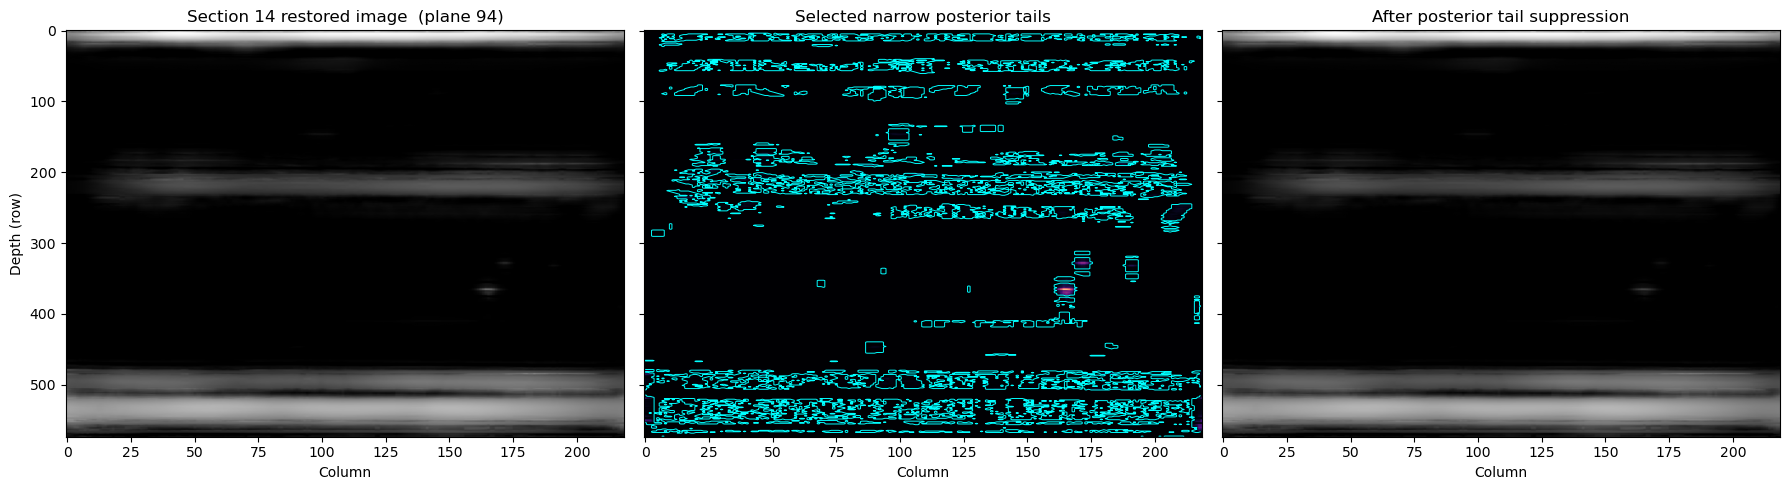

Tail-clean viewer after adding restored and final reconstructed volumes


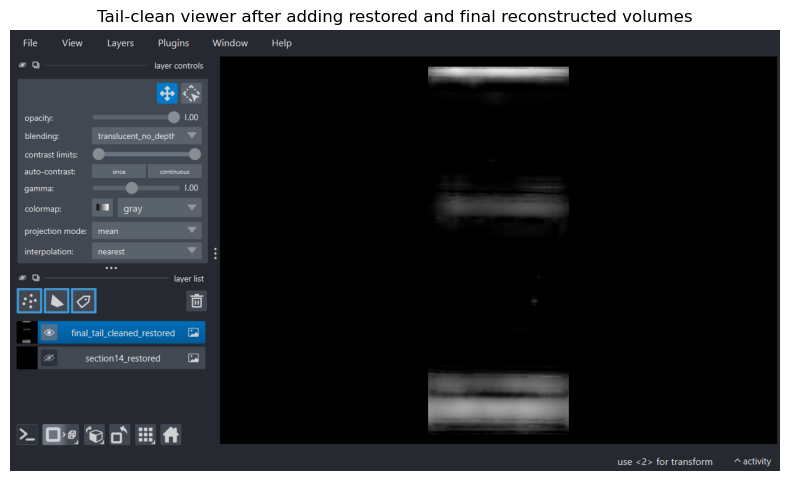


Artifact-mask voxel fractions (all methods):
      baseline: 0.0554
    hard_notch: 0.0535
    soft_notch: 0.0515
       wavelet: 0.0535
       swt_vol: 0.0493
     comb_gate: 0.0108
    tail_clean: 0.0106

Structure-preservation metrics:
      method | correlation | norm_RMSE | grad_E_ratio
  hard_notch |      0.8153 |    0.5791 |       0.6623
  soft_notch |      0.9313 |    0.3722 |       0.7259
     wavelet |      0.7147 |    0.7012 |       0.4737
     swt_vol |      0.8271 |    0.6054 |       0.3580
   comb_gate |      0.4636 |    0.9102 |       0.0452
  tail_clean |      0.4629 |    0.9116 |       0.0430

Napari contrast limits for final reconstructed volume: [0.9000, 198.0086]
Tail-clean viewer after adding final reconstructed volume with fixed contrast


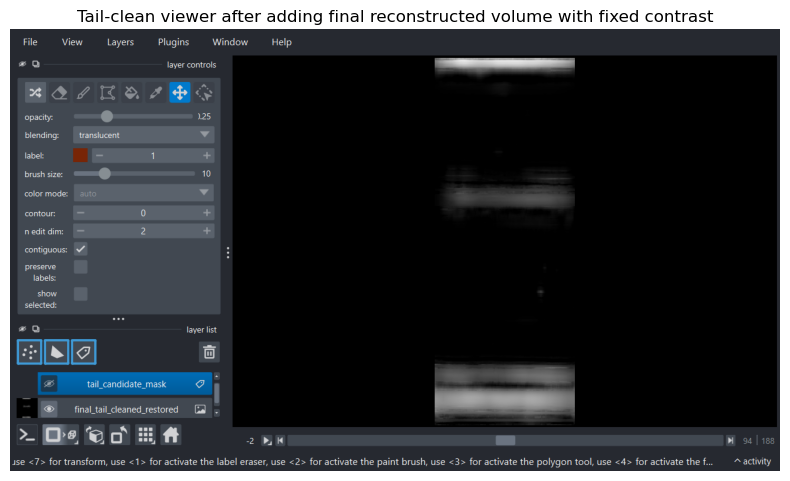

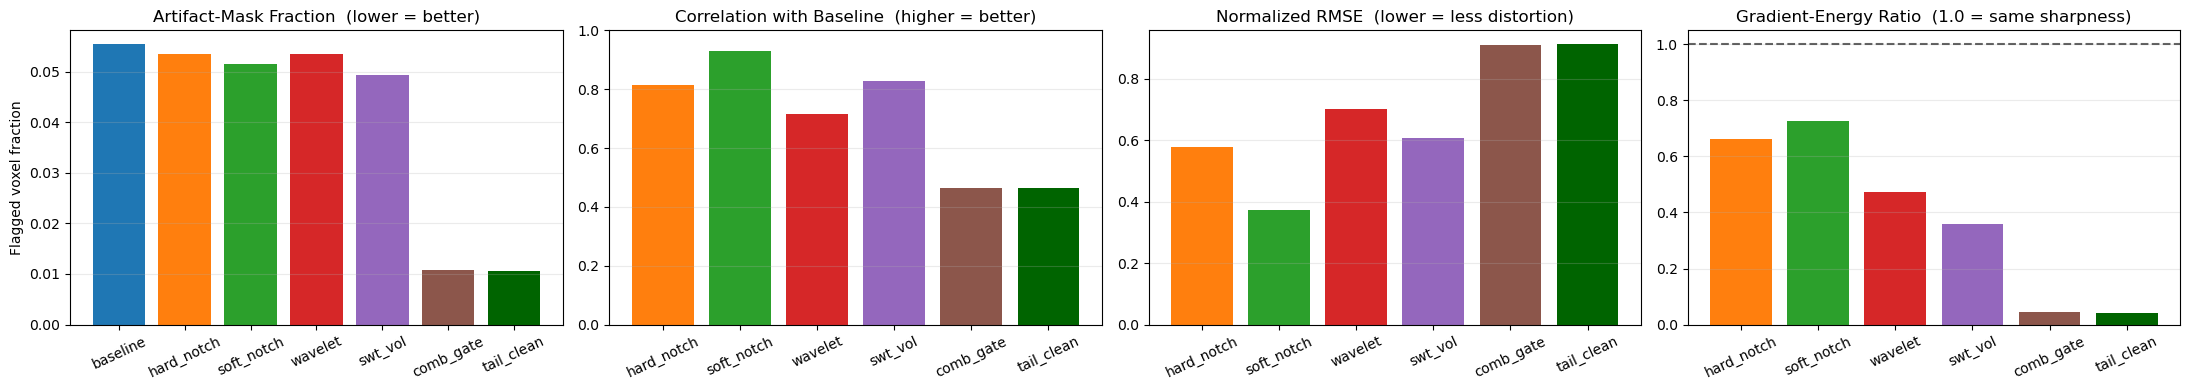

In [ ]:
# =============================================================================
# Section 15 - Short-depth posterior tail suppression
# Builds on final_cleaned_vol from Section 14.
# =============================================================================

# ---------------------------------------------------------------------------
# 1. SELECTIVE NARROW-X POSTERIOR TAIL DETECTOR
#    Keep only narrow-x bright residuals that appear within a short distance
#    below a brighter recent source in the same local x-neighborhood.
# ---------------------------------------------------------------------------
_positive_echo = np.maximum(final_cleaned_vol, 0.0).astype(np.float32)

_x_open_width = 9
_recent_depth = 8
_recent_x_width = 5
_tail_subtract_gain = 0.55
_tail_source_iqr_gain = 3.0
_tail_residual_iqr_gain = 3.0

# Narrow-x residuals: broad horizontal structures survive the opening,
# while thin posterior spikes/tails are isolated in the residual.
_x_opened = ndimage.grey_opening(_positive_echo, size=(1, 1, _x_open_width))
_narrow_x_residual = np.maximum(_positive_echo - _x_opened, 0.0)

# Bright recent sources that can plausibly generate short posterior tails.
_source_mask = np.zeros_like(_positive_echo, dtype=bool)
for _pi in range(plane_count):
    _plane = _positive_echo[_pi]
    _thr = np.median(_plane) + _tail_source_iqr_gain * (
        np.percentile(_plane, 75) - np.percentile(_plane, 25)
    )
    _source_mask[_pi] = _plane > _thr

# Allow a small lateral neighborhood around the source before propagating downward.
_source_mask_local = ndimage.maximum_filter(_source_mask.astype(np.uint8), size=(1, 1, _recent_x_width)) > 0
_recent_kernel = np.zeros(_recent_depth + 1, dtype=np.float32)
_recent_kernel[1:] = 1.0
_recent_source_support = signal.lfilter(_recent_kernel, [1.0], _source_mask_local.astype(np.float32), axis=1) > 0

# Final tail mask: narrow-x residual AND immediately below a recent bright source.
_tail_mask_volume = np.zeros_like(_positive_echo, dtype=bool)
for _pi in range(plane_count):
    _plane_res = _narrow_x_residual[_pi]
    _thr = np.median(_plane_res) + _tail_residual_iqr_gain * (
        np.percentile(_plane_res, 75) - np.percentile(_plane_res, 25)
    )
    _tail_mask_volume[_pi] = (_plane_res > _thr) & _recent_source_support[_pi]

_tail_subtraction = _tail_subtract_gain * _narrow_x_residual * _tail_mask_volume.astype(np.float32)
final_tail_cleaned_vol = (final_cleaned_vol - _tail_subtraction).astype(np.float32)

print('Posterior tail suppression parameters:')
print(f'  x opening width     : {_x_open_width} px')
print(f'  recent depth window : {_recent_depth} px')
print(f'  recent x window     : {_recent_x_width} px')
print(f'  subtraction gain    : {_tail_subtract_gain:.2f}')
print(f'  flagged tail voxels : {_tail_mask_volume.sum()} / {_tail_mask_volume.size}')
print(f'  mean subtraction    : {float(_tail_subtraction.mean()):.6f}')
print(f'  max subtraction     : {float(_tail_subtraction.max()):.6f}')

# ---------------------------------------------------------------------------
# 2. RECONSTRUCT IMAGE-DOMAIN VOLUMES FOR VISUALIZATION
#    final_cleaned_vol is a normalized high-pass result. For Napari, map it back
#    onto the original per-plane background so fixed contrast limits are usable.
# ---------------------------------------------------------------------------
section14_restored_volume = np.empty_like(volume, dtype=np.float32)
final_tail_cleaned_restored_volume = np.empty_like(volume, dtype=np.float32)

for _pi in range(plane_count):
    _plane = volume[_pi].astype(np.float32)
    _background = ndimage.gaussian_filter(_plane, sigma=(8, 8)).astype(np.float32)
    _hp_raw = (_plane - _background).astype(np.float32)
    _hp_mean = float(_hp_raw.mean())
    _hp_std = float(_hp_raw.std() + 1e-8)

    section14_restored_volume[_pi] = _background + final_cleaned_vol[_pi] * _hp_std + _hp_mean
    final_tail_cleaned_restored_volume[_pi] = _background + final_tail_cleaned_vol[_pi] * _hp_std + _hp_mean

section14_restored_volume = np.clip(section14_restored_volume, 0.0, None)
final_tail_cleaned_restored_volume = np.clip(final_tail_cleaned_restored_volume, 0.0, None)

# ---------------------------------------------------------------------------
# 3. VISUAL COMPARISON ON THE MIDDLE PLANE
# ---------------------------------------------------------------------------
_mid = plane_count // 2
figure, axis_array = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
axis_array[0].imshow(section14_restored_volume[_mid], cmap='gray', aspect='auto')
axis_array[0].set_title(f'Section 14 restored image  (plane {_mid})')
axis_array[0].set_xlabel('Column')
axis_array[0].set_ylabel('Depth (row)')

axis_array[1].imshow(_narrow_x_residual[_mid], cmap='magma', aspect='auto')
axis_array[1].contour(_tail_mask_volume[_mid].astype(np.uint8), levels=[0.5], colors='cyan', linewidths=0.7)
axis_array[1].set_title('Selected narrow posterior tails')
axis_array[1].set_xlabel('Column')

axis_array[2].imshow(final_tail_cleaned_restored_volume[_mid], cmap='gray', aspect='auto')
axis_array[2].set_title('After posterior tail suppression')
axis_array[2].set_xlabel('Column')

plt.tight_layout()
plt.show()

viewer_tail_clean = napari.Viewer(title='Posterior Tail QC')
viewer_tail_clean.add_image(section14_restored_volume, contrast_limits=[0, section14_restored_volume.max()], name='section14_restored', colormap='gray', visible=False)
viewer_tail_clean.add_image(final_tail_cleaned_restored_volume, contrast_limits=[0, final_tail_cleaned_restored_volume.max()], name='final_tail_cleaned_restored', colormap='gray')
capture_napari_screenshot(viewer_tail_clean, 'Tail-clean viewer after adding restored and final reconstructed volumes')
viewer_tail_clean.add_labels(_tail_mask_volume.astype(np.uint8), name='tail_candidate_mask', opacity=0.25, visible=False)

# ---------------------------------------------------------------------------
# 4. METRIC UPDATE (still computed in filtered high-pass domain)
# ---------------------------------------------------------------------------
artifact_fraction_by_method['tail_clean'] = compute_artifact_mask_fraction(final_tail_cleaned_vol)
structure_metrics_by_method['tail_clean'] = compute_structure_metrics(
    high_pass_volume, final_tail_cleaned_vol
)

print()
print('Artifact-mask voxel fractions (all methods):')
for _name, _frac in artifact_fraction_by_method.items():
    print(f'  {_name:>12s}: {_frac:.4f}')

print()
print('Structure-preservation metrics:')
print(f'{"method":>12s} | {"correlation":>11s} | {"norm_RMSE":>9s} | {"grad_E_ratio":>12s}')
for _name, (_corr, _rmse, _grad) in structure_metrics_by_method.items():
    print(f'{_name:>12s} | {_corr:11.4f} | {_rmse:9.4f} | {_grad:12.4f}')

# ---------------------------------------------------------------------------
# 5. NAPARI DISPLAY OF RECONSTRUCTED IMAGE-DOMAIN RESULT WITH FIXED LIMITS
# ---------------------------------------------------------------------------
_display_hi = float(final_tail_cleaned_restored_volume.max())
_display_lo = 0.9 if _display_hi > 0.9 else 0.0
print()
print(f'Napari contrast limits for final reconstructed volume: [{_display_lo:.4f}, {_display_hi:.4f}]')

try:
    capture_napari_screenshot(viewer_tail_clean, 'Tail-clean viewer after adding final reconstructed volume with fixed contrast')
except RuntimeError as _napari_err:
    print(f'Napari viewer not available ({_napari_err}). '
          'Re-run Cell 5 to reopen the viewer, then re-run this cell.')

# ---------------------------------------------------------------------------
# 6. FINAL BAR-CHART UPDATE
# ---------------------------------------------------------------------------
_all_m = list(artifact_fraction_by_method.keys())
_met_m = list(structure_metrics_by_method.keys())
_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
            'tab:purple', 'tab:brown', 'darkgreen', 'teal']

figure, axis_array = plt.subplots(1, 4, figsize=(22, 4))

axis_array[0].bar(_all_m, [artifact_fraction_by_method[m] for m in _all_m],
                  color=_palette[:len(_all_m)])
axis_array[0].set_title('Artifact-Mask Fraction  (lower = better)')
axis_array[0].set_ylabel('Flagged voxel fraction')
axis_array[0].grid(axis='y', alpha=0.25)
axis_array[0].tick_params(axis='x', rotation=25)

axis_array[1].bar(_met_m, [structure_metrics_by_method[m][0] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[1].set_title('Correlation with Baseline  (higher = better)')
axis_array[1].set_ylim(0.0, 1.0)
axis_array[1].grid(axis='y', alpha=0.25)
axis_array[1].tick_params(axis='x', rotation=25)

axis_array[2].bar(_met_m, [structure_metrics_by_method[m][1] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[2].set_title('Normalized RMSE  (lower = less distortion)')
axis_array[2].grid(axis='y', alpha=0.25)
axis_array[2].tick_params(axis='x', rotation=25)

axis_array[3].bar(_met_m, [structure_metrics_by_method[m][2] for m in _met_m],
                  color=_palette[1:len(_met_m) + 1])
axis_array[3].set_title('Gradient-Energy Ratio  (1.0 = same sharpness)')
axis_array[3].axhline(1.0, linestyle='--', color='k', alpha=0.6)
axis_array[3].grid(axis='y', alpha=0.25)
axis_array[3].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
